<h1><b>ACV Refrigerant Leak Model Training</b></h1>

<h4><b>Background Information</b></h4>

The ACV subsystem in NEBULA X Problem Statement 3 asks for the cars of a train to be ranked from most to least
likely to be leaking refrigerant. Each workbook is scored with the linear rank decay `(n - (r - 1)) / n`, where
`r` is the rank given to the leaking car among `n` cars, and the subsystem score is the mean over workbooks. Six
labelled Train cases and one unlabelled Test case are available, so every result rests on six independent
examples.

<h4><b>Objective</b></h4>

This notebook builds car-ranking models from a simple baseline upwards and evaluates each one on held-out Train
cases with the official score. Every model architecture is tracked as its own MLflow experiment on DagsHub
(`acv_baseline`, `acv_logistic_ranker`, `acv_gbm_ranker`, `acv_peer_residual`), the architectures are compared,
and the selected model is refitted, registered and used to rank the cars of the Test case.

<h4><b>Project Workflow</b></h4>

The notebook sets up the environment and experiment tracking, loads the preprocessed data and assembles the
features, defines the performance metrics and the shared model utilities, and then builds four architectures of
increasing complexity: fixed peer-anomaly rules, a pairwise logistic ranker, a gradient-boosted LambdaRank model,
and a peer-residual model that learns the expected cabin temperature. The architectures are then compared, one is
selected, refitted and registered, and the Test ranking is produced.

<h4><b>Dataset Used</b></h4>

The inputs are the outputs of `acv_preprocessing.ipynb` in `data/processed/acv`: the case-and-car feature table,
the one-minute grid, the cleaned readings, the parameter mapping and the preprocessing manifest. The raw workbooks
and `Train_Labels.csv` in `PS3/02_Datasets/ACV` are used only to confirm fingerprints and labels.

<h4><b>Table of Contents</b></h4>
<ul>
  <li><a href="#section-1">Section 1: Environment Setup</a>
    <ul>
      <li><a href="#1-1">1.1 Libraries and Settings</a></li>
      <li><a href="#1-2">1.2 Paths and Configuration</a></li>
      <li><a href="#1-3">1.3 Experiment Tracking</a></li>
    </ul>
  </li>
  <li><a href="#section-2">Section 2: Data and Features</a>
    <ul>
      <li><a href="#2-1">2.1 Preprocessed Tables</a></li>
      <li><a href="#2-2">2.2 Source Check and Data Version</a></li>
      <li><a href="#2-3">2.3 Labels and Cases</a></li>
      <li><a href="#2-4">2.4 Invalid Readings by Car</a></li>
      <li><a href="#2-5">2.5 Persistence of Poor Cooling</a></li>
      <li><a href="#2-6">2.6 Recovery After Cooling Restarts</a></li>
      <li><a href="#2-7">2.7 Cooling Share Without Invalid Minutes</a></li>
      <li><a href="#2-8">2.8 Per-Reading Peer Differences</a></li>
      <li><a href="#2-9">2.9 Car Feature Table</a></li>
      <li><a href="#2-10">2.10 Within-Case Standardisation</a></li>
      <li><a href="#2-11">2.11 Test Feature Coverage</a></li>
    </ul>
  </li>
  <li><a href="#section-3">Section 3: Performance Metrics</a>
    <ul>
      <li><a href="#3-1">3.1 Rank-Decay Score</a></li>
      <li><a href="#3-2">3.2 Held-Out Summary</a></li>
      <li><a href="#3-3">3.3 Evaluation Plots</a></li>
      <li><a href="#3-4">3.4 Recording Evaluations in MLflow</a></li>
    </ul>
  </li>
  <li><a href="#section-4">Section 4: Model Utilities</a>
    <ul>
      <li><a href="#4-1">4.1 Ranking Cars</a></li>
      <li><a href="#4-2">4.2 Validation Splits</a></li>
      <li><a href="#4-3">4.3 Cross-Validation</a></li>
      <li><a href="#4-4">4.4 Experiment Runner</a></li>
    </ul>
  </li>
  <li><a href="#section-5">Section 5: Baseline: Peer-Anomaly Rules</a>
    <ul>
      <li><a href="#5-1">5.1 Rule Ranker</a></li>
      <li><a href="#5-2">5.2 Median Peer Difference</a></li>
      <li><a href="#5-3">5.3 Mean Peer Difference</a></li>
      <li><a href="#5-4">5.4 Median and Mean Compared</a></li>
    </ul>
  </li>
  <li><a href="#section-6">Section 6: Pairwise Logistic Ranker</a>
    <ul>
      <li><a href="#6-1">6.1 Pairwise Training Examples</a></li>
      <li><a href="#6-2">6.2 Logistic Ranker</a></li>
      <li><a href="#6-3">6.3 All Features</a></li>
      <li><a href="#6-4">6.4 Feature-Group Ablations</a></li>
      <li><a href="#6-5">6.5 Adding the Invalid-State Share</a></li>
      <li><a href="#6-6">6.6 Robustness Checks</a></li>
      <li><a href="#6-7">6.7 Learned Weights</a></li>
    </ul>
  </li>
  <li><a href="#section-7">Section 7: Gradient-Boosted Ranker</a>
    <ul>
      <li><a href="#7-1">7.1 LambdaRank Ranker</a></li>
      <li><a href="#7-2">7.2 LambdaRank on All Features</a></li>
      <li><a href="#7-3">7.3 Feature Importance</a></li>
    </ul>
  </li>
  <li><a href="#section-8">Section 8: Peer-Residual Model</a>
    <ul>
      <li><a href="#8-1">8.1 Minute Table</a></li>
      <li><a href="#8-2">8.2 Peer-Residual Ranker</a></li>
      <li><a href="#8-3">8.3 Ridge Regression</a></li>
      <li><a href="#8-4">8.4 Histogram Gradient Boosting</a></li>
      <li><a href="#8-5">8.5 Residuals of Healthy and Leaking Cars</a></li>
    </ul>
  </li>
  <li><a href="#section-9">Section 9: Model Comparison</a>
    <ul>
      <li><a href="#9-1">9.1 Results Across Experiments</a></li>
      <li><a href="#9-2">9.2 Comparison Plot</a></li>
      <li><a href="#9-3">9.3 Model Selection</a></li>
    </ul>
  </li>
  <li><a href="#section-10">Section 10: Final Model</a>
    <ul>
      <li><a href="#10-1">10.1 Refit on All Train Cases</a></li>
      <li><a href="#10-2">10.2 Model Package</a></li>
      <li><a href="#10-3">10.3 Registration</a></li>
      <li><a href="#10-4">10.4 Submission Format</a></li>
      <li><a href="#10-5">10.5 Package Checks</a></li>
      <li><a href="#10-6">10.6 Test-Case Ranking</a></li>
      <li><a href="#10-7">10.7 Evidence Margin</a></li>
    </ul>
  </li>
  <li><a href="#section-11">Section 11: Conclusions</a>
    <ul>
      <li><a href="#11-1">11.1 Results by Architecture</a></li>
      <li><a href="#11-2">11.2 Selected Model and Test Ranking</a></li>
      <li><a href="#11-3">11.3 Limitations</a></li>
    </ul>
  </li>
</ul>

<hr>

<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-1" style="color: black;"><b>Section 1: Environment Setup</b></h2>
</div>

This section imports the libraries, locates the data, fixes the settings used throughout, and connects MLflow to
the project's DagsHub repository.

<blockquote><h3 id="1-1"><b>1.1 Libraries and Settings</b></h3></blockquote>

The notebook uses pandas and NumPy for data handling, SciPy for intervals, scikit-learn and LightGBM for the
learned models, and MLflow with DagsHub for experiment tracking. A fixed seed makes every result reproducible.

In [1]:
from pathlib import Path
import io
import os
import json
import time
import uuid
import hashlib
import logging
import warnings
import itertools
import contextlib
import subprocess
import importlib.metadata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import lightgbm as lgb
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
import mlflow
import mlflow.pyfunc
from mlflow import MlflowClient
from mlflow.models import infer_signature
from IPython.display import display

SEED = 2026
COLORS = {'Affected car': '#d95f38', 'Other car': '#16857b', 'candidate': '#2878a5', 'variant': '#9a9a9a'}
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
                     'figure.constrained_layout.use': True})
pd.set_option('display.max_columns', 40)
pd.set_option('display.max_rows', 120)
pd.set_option('display.width', 170)
for logger_name in ['mlflow', 'alembic']:
    logging.getLogger(logger_name).setLevel(logging.WARNING)  # MLflow resets its level on import, so set it after

<blockquote><h3 id="1-2"><b>1.2 Paths and Configuration</b></h3></blockquote>

The data folders are found from the working directory; `TFD_PS3_DIR` and `TFD_PROCESSED_DIR` override them. Every
setting that affects the results is gathered in one configuration, which each MLflow run records.

In [2]:
def find_repo_root():
    """Nearest ancestor of the working directory that holds `pyproject.toml`."""
    for base in [Path.cwd(), *Path.cwd().parents]:
        if (base / 'pyproject.toml').is_file():
            return base
    return Path.cwd()


def find_dataset(subsystem):
    """Locate a PS3 subsystem folder from `TFD_PS3_DIR` or the working directory and its parents."""
    if os.environ.get('TFD_PS3_DIR'):
        root = Path(os.environ['TFD_PS3_DIR']).expanduser()
        candidates = [root / subsystem, root / '02_Datasets' / subsystem]
    else:
        suffixes = ['problem-statement/PS3/02_Datasets', 'PS3/02_Datasets', '02_Datasets']
        candidates = [base / suffix / subsystem for base in [Path.cwd(), *Path.cwd().parents] for suffix in suffixes]
    for candidate in candidates:
        if candidate.is_dir():
            return candidate.resolve()
    raise FileNotFoundError(f'{subsystem} not found; set TFD_PS3_DIR to the PS3 or 02_Datasets folder.')


REPO_ROOT = find_repo_root()
ACV_DIR = find_dataset('ACV')
PROCESSED_DIR = Path(os.environ.get('TFD_PROCESSED_DIR', REPO_ROOT / 'data' / 'processed')) / 'acv'
OUTPUT_DIR = PROCESSED_DIR / 'training'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CONFIG = {
    'seed': SEED,
    'registered_model': 'acv_car_ranker',
    'dagshub': {'repo_owner': 'kaz-uuu', 'repo_name': 'lta-train-fault-detection'},
    'min_peers': 3,
    'warm_margin_c': 1.0,
    'recovery_horizon_min': 30,
    'recovery_min_points': 10,
    'c_grid': [0.01, 0.1, 1.0],
    'lambdarank': {'n_estimators': 100, 'learning_rate': 0.05, 'num_leaves': 4, 'min_child_samples': 3},
    'ridge_alpha': 1.0,
    'hist_gradient_boosting': {'max_iter': 200, 'learning_rate': 0.1, 'max_leaf_nodes': 15},
    'bootstrap_draws': 10000,
}
def flatten(settings, prefix=''):
    """Nested settings as one mapping with dotted keys."""
    flat = {}
    for key, value in settings.items():
        flat.update(flatten(value, f'{prefix}{key}.') if isinstance(value, dict) else {f'{prefix}{key}': value})
    return flat


display(pd.Series(flatten(CONFIG), name='value').to_frame())

,value
seed,2026
registered_model,acv_car_ranker
dagshub.repo_owner,kaz-uuu
dagshub.repo_name,lta-train-fault-detection
min_peers,3
warm_margin_c,1.0
recovery_horizon_min,30
recovery_min_points,10
c_grid,"[0.01, 0.1, 1.0]"
lambdarank.n_estimators,100


<blockquote><h3 id="1-3"><b>1.3 Experiment Tracking</b></h3></blockquote>

MLflow logs to the DagsHub repository `kaz-uuu/lta-train-fault-detection` through `dagshub.init`, using the login
stored on this machine by `dagshub login`. Each model architecture gets its own experiment named
`acv_<architecture>`, and each evaluated configuration is one run inside it. The runs of one execution share a
`notebook_run` tag so that the comparison later reads back exactly this execution. Setting `TFD_MLFLOW=local`
logs to a local SQLite store instead, and an explicit `MLFLOW_TRACKING_URI` takes precedence over both.

In [3]:
TRACKING = 'uri' if os.environ.get('MLFLOW_TRACKING_URI') else os.environ.get('TFD_MLFLOW', 'dagshub')
if TRACKING == 'dagshub':
    import dagshub
    dagshub.init(repo_owner=CONFIG['dagshub']['repo_owner'], repo_name=CONFIG['dagshub']['repo_name'], mlflow=True)
elif TRACKING == 'local':
    mlflow.set_tracking_uri(f"sqlite:///{(REPO_ROOT / 'mlflow.db').as_posix()}")
TRACKING_URI = mlflow.get_tracking_uri()
mlflow.set_registry_uri(TRACKING_URI)
client = MlflowClient()
NOTEBOOK_RUN = uuid.uuid4().hex[:8]


def git(*args):
    """Output of a git command run in the repository, or an empty string when git is unavailable."""
    try:
        return subprocess.run(['git', *args], cwd=REPO_ROOT, capture_output=True, text=True, timeout=10).stdout.strip()
    except (OSError, subprocess.SubprocessError):
        return ''


GIT = {'git_commit': git('rev-parse', '--short', 'HEAD') or 'unknown',
       'git_branch': git('rev-parse', '--abbrev-ref', 'HEAD') or 'unknown'}


def experiment_id(name):
    """Id of the MLflow experiment `name`, created on first use."""
    found = client.get_experiment_by_name(name)
    if found is not None:
        return found.experiment_id
    location = (REPO_ROOT / 'mlartifacts').as_uri() if TRACKING_URI.startswith('sqlite') else None
    return client.create_experiment(name, artifact_location=location)


print('Tracking to:', TRACKING_URI if TRACKING != 'local' else 'local SQLite store (mlflow.db)')
print('Runs of this execution are tagged notebook_run =', NOTEBOOK_RUN)

Accessing as kaz-uuu

Initialized MLflow to track repo "kaz-uuu/lta-train-fault-detection"

Repository kaz-uuu/lta-train-fault-detection initialized!

Tracking to: https://dagshub.com/kaz-uuu/lta-train-fault-detection.mlflow
Runs of this execution are tagged notebook_run = 588fdf5c


<hr>

<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-2" style="color: black;"><b>Section 2: Data and Features</b></h2>
</div>

This section loads the preprocessed tables, confirms they still match the raw workbooks, checks the labels, and
assembles one row of features per case and car. Several choices follow from the exploratory analysis: the cases
differ in sampling rate, so every feature is computed on the one-minute grid; cars without any cabin temperature
must still be ranked; invalid running states cluster on the leaking car and may encode an existing fault flag, so
they are kept out of the model features; and medians hide the leaking car because temperatures are recorded in
0.5-degree steps. Per-car tables are shown for Train cases only.

<blockquote><h3 id="2-1"><b>2.1 Preprocessed Tables</b></h3></blockquote>

Four tables from the preprocessing notebook are read: the case-and-car feature table, the one-minute grid, the
cleaned readings (only the columns needed here) and the parameter mapping, together with the preprocessing
manifest.

In [4]:
car_features = pd.read_parquet(PROCESSED_DIR / 'acv_car_features.parquet')
minutes = (pd.read_parquet(PROCESSED_DIR / 'acv_minutes.parquet')
           .sort_values(['case', 'car', 'minute']).reset_index(drop=True))
readings = pd.read_parquet(PROCESSED_DIR / 'acv_readings.parquet',
                           columns=['case', 'car', 'time', 'indoor', 'mode_group', 'invalid'])
mapping = pd.read_parquet(PROCESSED_DIR / 'acv_parameter_mapping.parquet')
prep_manifest = json.loads((PROCESSED_DIR / 'manifest.json').read_text())
display(pd.DataFrame({name: {'rows': len(t), 'columns': t.shape[1]} for name, t in {
    'car features': car_features, 'one-minute grid': minutes, 'readings': readings, 'parameter mapping': mapping}.items()}).T)

,rows,columns
car features,56,39
one-minute grid,182284,16
readings,408517,6
parameter mapping,392,6


<blockquote><h3 id="2-2"><b>2.2 Source Check and Data Version</b></h3></blockquote>

The fingerprint of every raw workbook is recomputed and compared with the preprocessing manifest; a mismatch means
the preprocessed tables describe different data and stops the notebook. A short data version, derived from the
fingerprints of the preprocessed tables, is attached to every MLflow run.

In [5]:
def sha256_file(path):
    """SHA-256 of a file's bytes."""
    return hashlib.sha256(Path(path).read_bytes()).hexdigest()


raw_paths = {p.name: p for p in sorted(ACV_DIR.glob('*/*.xlsx'))}
mismatched = [name for name, digest in prep_manifest['sources'].items() if sha256_file(raw_paths[name]) != digest]
assert not mismatched, f'Workbooks changed since preprocessing: {mismatched}; rerun acv_preprocessing.ipynb.'
TABLES = ['acv_car_features.parquet', 'acv_minutes.parquet', 'acv_readings.parquet', 'acv_parameter_mapping.parquet']
DATA_VERSION = 'acv-' + hashlib.sha256(''.join(sha256_file(PROCESSED_DIR / t) for t in TABLES).encode()).hexdigest()[:8]
print(f'All {len(prep_manifest["sources"])} raw workbooks match the preprocessing fingerprints; data version {DATA_VERSION}.')

All 7 raw workbooks match the preprocessing fingerprints; data version acv-4e6e2d95.


<blockquote><h3 id="2-3"><b>2.3 Labels and Cases</b></h3></blockquote>

The leaking car of each Train case is taken from the feature table and checked against `Train_Labels.csv` read
as text, which keeps the two-digit car identifiers intact. The table lists each case with its car model, train
number, cars with cabin-temperature evidence and leaking car. Cases 01 and 02 come from the same train as the
Test case, which is why a leave-one-train-out check appears later.

In [6]:
FILE_ID = mapping.drop_duplicates('case').set_index('case')['workbook'].to_dict()
CASE_OF = {file_id: case for case, file_id in FILE_ID.items()}
POSITIVES = car_features[car_features['label'].eq(1).fillna(False)].set_index('case')['car'].astype(str)
TRAIN_CASES = sorted(POSITIVES.index)
raw_labels = pd.read_csv(ACV_DIR / 'Train_Labels.csv', dtype=str).assign(case=lambda t: t['filename'].map(CASE_OF))
assert raw_labels.set_index('case')['faulty_car'].reindex(TRAIN_CASES).equals(POSITIVES.reindex(TRAIN_CASES))
cases = car_features.groupby('case').agg(dataset=('dataset', 'first'), car_model=('car_model', 'first'),
                                         train_number=('train_number', 'first'), cars=('car', 'size'),
                                         cars_with_indoor=('has_indoor', 'sum'))
cases['leaking car'] = POSITIVES.reindex(cases.index)
display(cases)

,dataset,car_model,train_number,cars,cars_with_indoor,leaking car
case,,,,,,
case_01,Train,A,620,8,8,01
case_02,Train,A,620,8,8,02
case_03,Train,A,619,8,8,03
case_04,Train,B,208,8,4,01
case_05,Train,C,407,8,8,04
case_06,Train,C,408,8,8,06
test_case,Test,A,620,8,8,NaN


<blockquote><h3 id="2-4"><b>2.4 Invalid Readings by Car</b></h3></blockquote>

The preprocessing notebook masked readings in an invalid running state. Counting them per car shows where they
fall; the Test case is shown only as a total, so that no car-level Test pattern can influence the modelling.

In [7]:
invalid_counts = readings.groupby(['case', 'car'])['invalid'].sum().unstack('car').fillna(0).astype(int)
display(invalid_counts.reindex(TRAIN_CASES).assign(**{'leaking car': POSITIVES}))
print('Invalid readings in test_case, all cars together:', int(invalid_counts.loc['test_case'].sum()))

car,01,02,03,04,05,06,07,08,leaking car
case,,,,,,,,,
case_01,56,0,0,0,0,0,0,0,01
case_02,0,45,1,1,0,1,1,0,02
case_03,0,0,1,0,0,0,0,0,03
case_04,0,0,0,0,0,0,0,0,01
case_05,0,0,0,0,0,0,0,0,04
case_06,0,0,0,0,0,0,0,0,06


Invalid readings in test_case, all cars together: 26


<blockquote><h3 id="2-5"><b>2.5 Persistence of Poor Cooling</b></h3></blockquote>

Labels give no fault-onset time, and a leaking car can deviate for only part of a recording. Persistence is
therefore measured as the longest run of consecutive grid minutes in which a car is cooling and more than 1 degree
above its target. Runs never bridge gaps in the grid.

In [8]:
def longest_warm_run(group, margin):
    """Longest run of consecutive grid minutes spent cooling and more than `margin` degrees above target."""
    warm = (group['cooling'] & group['target_error'].gt(margin)).to_numpy()
    joined = group['minute'].diff().eq(pd.Timedelta('1min')).to_numpy()
    best = run = 0
    for is_warm, is_joined in zip(warm, joined):
        run = run + 1 if (is_warm and is_joined and run > 0) else int(is_warm)
        best = max(best, run)
    return best


persistence = (minutes.groupby(['case', 'car'])
               .apply(lambda g: longest_warm_run(g, CONFIG['warm_margin_c']), include_groups=False)
               .rename('longest_warm_run_min'))
display(persistence.unstack('car').reindex(TRAIN_CASES))

car,01,02,03,04,05,06,07,08
case,,,,,,,,
case_01,109.0,39.0,16.0,16.0,15.0,15.0,15.0,14.0
case_02,42.0,46.0,40.0,16.0,9.0,16.0,39.0,26.0
case_03,38.0,56.0,121.0,56.0,26.0,25.0,56.0,17.0
case_04,22.0,8.0,19.0,58.0,NaN,NaN,NaN,NaN
case_05,5.0,6.0,4.0,11.0,3.0,5.0,6.0,4.0
case_06,38.0,45.0,48.0,48.0,45.0,115.0,38.0,51.0


<blockquote><h3 id="2-6"><b>2.6 Recovery After Cooling Restarts</b></h3></blockquote>

A unit that has lost refrigerant should pull the cabin temperature down more slowly after cooling restarts. Every
move from a stopped or ventilating minute to a cooling minute one minute later counts as a restart; the
cabin-temperature slope over the next 30 cooling minutes is fitted when at least 10 are available, and each car
takes the median slope over its restarts. The table gives the number of usable restarts per car.

In [9]:
def recovery_slope(group, horizon, min_points):
    """Median cabin-temperature slope (degrees per minute) over the first `horizon` minutes after each restart."""
    group = group.reset_index(drop=True)
    state = group['mode_group'].fillna('')
    restart = (state.eq('cooling') & state.shift().isin(['stopped', 'ventilation'])
               & group['minute'].diff().eq(pd.Timedelta('1min'))).to_numpy(dtype=bool)
    slopes = []
    for i in np.flatnonzero(restart):
        elapsed = (group['minute'] - group.at[i, 'minute']).dt.total_seconds() / 60
        window = group[elapsed.between(0, horizon) & group['cooling'] & group['indoor'].notna()]
        if len(window) >= min_points:
            t = (window['minute'] - window['minute'].iloc[0]).dt.total_seconds() / 60
            slopes.append(np.polyfit(t, window['indoor'], 1)[0])
    return pd.Series({'recovery_events': len(slopes), 'recovery_slope': np.median(slopes) if slopes else np.nan})


recovery = minutes.groupby(['case', 'car']).apply(
    lambda g: recovery_slope(g, CONFIG['recovery_horizon_min'], CONFIG['recovery_min_points']), include_groups=False)
display(recovery['recovery_events'].unstack('car').reindex(TRAIN_CASES))

car,01,02,03,04,05,06,07,08
case,,,,,,,,
case_01,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0
case_02,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0
case_03,3.0,4.0,4.0,3.0,3.0,4.0,4.0,4.0
case_04,40.0,17.0,19.0,18.0,NaN,NaN,NaN,NaN
case_05,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0
case_06,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0


<blockquote><h3 id="2-7"><b>2.7 Cooling Share Without Invalid Minutes</b></h3></blockquote>

The preprocessing cooling share counts invalid minutes in its denominator, so a car with many invalid minutes
looks as if it cools less, which would let the invalid state into the models by the back door. The share is
recomputed over valid-state minutes only; the table compares both versions for the leaking car of each Train case,
with its rank as the car that cools least.

In [10]:
valid_state = (minutes['mode_group'].notna() & minutes['mode_group'].ne('invalid')).fillna(False).to_numpy(dtype=bool)
cooling_share_valid = minutes[valid_state].groupby(['case', 'car'])['cooling'].mean().rename('cooling_share_valid')
prep_share = car_features.set_index(['case', 'car'])['cooling_share']
share_rows = []
for case in TRAIN_CASES:
    both = pd.concat([prep_share.loc[case], cooling_share_valid.loc[case]], axis=1)
    leaking = POSITIVES[case]
    share_rows.append({'case': case, 'leaking car': leaking,
                       'share (all minutes)': both.loc[leaking, 'cooling_share'],
                       'rank as lowest (all minutes)': int(both['cooling_share'].rank(method='min')[leaking]),
                       'share (valid minutes)': both.loc[leaking, 'cooling_share_valid'],
                       'rank as lowest (valid minutes)': int(both['cooling_share_valid'].rank(method='min')[leaking])})
display(pd.DataFrame(share_rows).set_index('case').round(4))

,leaking car,share (all minutes),rank as lowest (all minutes),share (valid minutes),rank as lowest (valid minutes)
case,,,,,
case_01,01,0.9245,1,0.9311,8
case_02,02,0.9874,1,0.9929,8
case_03,03,0.9891,2,0.9891,2
case_04,01,0.9406,1,0.9406,1
case_05,04,0.9859,1,0.9859,1
case_06,06,0.9419,3,0.9419,3


<blockquote><h3 id="2-8"><b>2.8 Per-Reading Peer Differences</b></h3></blockquote>

The exploratory analysis compared every eligible reading with the median of the other cars at the same timestamp,
requiring at least three peers, and summarised each car by the median difference. The same per-reading
differences are computed here from the cleaned readings (cooling, not invalid, with a cabin temperature), and each
car is summarised by both their median and their mean. The table counts the cars whose median difference is
exactly zero.

In [11]:
eligible = readings['mode_group'].eq('cooling').fillna(False) & ~readings['invalid'] & readings['indoor'].notna()
peer_rows = []
for case, sub in readings.assign(value=readings['indoor'].where(eligible)).groupby('case'):
    wide = sub.pivot_table(index='time', columns='car', values='value', aggfunc='first')
    for car in wide.columns:
        peers = wide.drop(columns=car)
        delta = (wide[car] - peers.median(axis=1)).where(peers.notna().sum(axis=1) >= CONFIG['min_peers']).dropna()
        peer_rows.append({'case': case, 'car': str(car), 'peer_delta_reading_median': delta.median(),
                          'peer_delta_reading_mean': delta.mean()})
reading_peer = pd.DataFrame(peer_rows).set_index(['case', 'car'])
display(reading_peer['peer_delta_reading_median'].eq(0).groupby('case').sum().reindex(TRAIN_CASES)
        .rename('cars with a median peer difference of 0').to_frame())

,cars with a median peer difference of 0
case,
case_01,8
case_02,8
case_03,7
case_04,4
case_05,7
case_06,6


<blockquote><h3 id="2-9"><b>2.9 Car Feature Table</b></h3></blockquote>

All features are joined into one row per case and car, keyed by the workbook file name as `file_id`. The model
features combine cabin-minus-target temperature, peer differences, their upper tails, persistence, ambient
context, the valid-state cooling share and recovery. The invalid-state share is added for one clearly marked
variant only, and the median peer difference for the exploratory baseline. The table counts missing values per
case; the only gaps are the silent cars of `case_04`.

In [12]:
FEATURES = ['target_error_cooling_mean', 'target_error_cooling_p90', 'above_target_share_cooling',
            'peer_delta_cooling_mean', 'peer_delta_cooling_p90', 'peer_delta_hot_mean',
            'indoor_outdoor_slope_cooling', 'cooling_share_valid', 'longest_warm_run_min', 'recovery_slope']
invalid_share = readings.groupby(['case', 'car'])['invalid'].mean().rename('invalid_share')
CAR_TABLE = (car_features[['case', 'car', 'dataset', 'car_model', 'train_number', 'label', 'minutes_with_indoor',
                           'target_error_cooling_mean', 'target_error_cooling_p90', 'above_target_share_cooling',
                           'peer_delta_cooling_mean', 'peer_delta_cooling_p90', 'peer_delta_hot_mean',
                           'indoor_outdoor_slope_cooling', 'cooling_share']]
             .join(cooling_share_valid, on=['case', 'car']).join(persistence, on=['case', 'car'])
             .join(recovery, on=['case', 'car']).join(invalid_share, on=['case', 'car']).join(reading_peer, on=['case', 'car']))
CAR_TABLE.insert(0, 'file_id', CAR_TABLE['case'].map(FILE_ID))
numeric = CAR_TABLE.columns[CAR_TABLE.columns.get_loc('minutes_with_indoor'):]
CAR_TABLE[numeric] = CAR_TABLE[numeric].astype(float)
CAR_TABLE[['case', 'car']] = CAR_TABLE[['case', 'car']].astype(str)
CAR_TABLE = CAR_TABLE.sort_values(['file_id', 'car']).reset_index(drop=True)
print('Car feature table:', CAR_TABLE.shape)
display(CAR_TABLE.groupby('case')[FEATURES + ['invalid_share', 'peer_delta_reading_median']]
        .agg(lambda s: int(s.isna().sum())).rename_axis('missing values'))

Car feature table: (56, 23)


,target_error_cooling_mean,target_error_cooling_p90,above_target_share_cooling,peer_delta_cooling_mean,peer_delta_cooling_p90,peer_delta_hot_mean,indoor_outdoor_slope_cooling,cooling_share_valid,longest_warm_run_min,recovery_slope,invalid_share,peer_delta_reading_median
missing values,,,,,,,,,,,,
case_01,0,0,0,0,0,0,0,0,0,0,0,0
case_02,0,0,0,0,0,0,0,0,0,0,0,0
case_03,0,0,0,0,0,0,0,0,0,0,0,0
case_04,4,4,4,4,4,4,4,4,4,4,4,4
case_05,0,0,0,0,0,0,0,0,0,0,0,0
case_06,0,0,0,0,0,0,0,0,0,0,0,0
test_case,0,0,0,0,0,0,0,0,0,0,0,0


<blockquote><h3 id="2-10"><b>2.10 Within-Case Standardisation</b></h3></blockquote>

A car can only be compared with the other cars of its own workbook, because season, car model and setpoints
differ between cases. Each feature is therefore turned into a robust z-score within its workbook: the distance
from the workbook median divided by 1.4826 times the median absolute deviation, with a floor on the scale so that
near-identical cars do not produce extreme values. The transformation uses no labels and no other workbook. The
z-scores of the features shared with preprocessing are checked against the preprocessing output.

In [13]:
SCALE_FLOOR = {'cooling_share': 0.01, 'target_error_cooling_mean': 0.1, 'target_error_cooling_p90': 0.1,
               'above_target_share_cooling': 0.01, 'peer_delta_cooling_mean': 0.1, 'peer_delta_cooling_p90': 0.1,
               'peer_delta_hot_mean': 0.1, 'indoor_outdoor_slope_cooling': 0.01, 'cooling_share_valid': 0.01,
               'longest_warm_run_min': 5.0, 'recovery_slope': 0.005, 'invalid_share': 0.001,
               'peer_delta_reading_median': 0.1, 'mean_residual': 0.1}


def robust_z(values, floor):
    """Distance from the median in units of 1.4826 x MAD, with the scale floored at `floor`."""
    centre = values.median()
    scale = max(1.4826 * (values - centre).abs().median(), floor)
    return (values - centre) / scale


def within_case_z(frame, features):
    """Robust z-score of each feature among the cars of the same workbook."""
    by_file = frame.groupby('file_id')
    return pd.DataFrame({f: by_file[f].transform(robust_z, SCALE_FLOOR[f]) for f in features}, index=frame.index)


shared = ['cooling_share', 'target_error_cooling_mean', 'target_error_cooling_p90', 'above_target_share_cooling',
          'peer_delta_cooling_mean', 'peer_delta_cooling_p90', 'peer_delta_hot_mean', 'indoor_outdoor_slope_cooling']
reproduced = within_case_z(CAR_TABLE, shared).set_index(pd.MultiIndex.from_frame(CAR_TABLE[['case', 'car']]))
saved = car_features.set_index(['case', 'car'])[[f'{f}_z' for f in shared]].set_axis(shared, axis=1).reindex(reproduced.index)
assert np.allclose(reproduced.to_numpy(float), saved.to_numpy(float), equal_nan=True)
print('The within-case z-scores reproduce the preprocessing output for all', len(shared), 'shared features.')

The within-case z-scores reproduce the preprocessing output for all 8 shared features.


<blockquote><h3 id="2-11"><b>2.11 Test Feature Coverage</b></h3></blockquote>

The Test case should sit inside the range seen in Train. For every model feature, the table counts Test cars
outside the Train range, both on the raw scale and on the within-case z-scores that the models use. No Test car is
ranked here.

In [14]:
is_test = CAR_TABLE['dataset'].eq('Test')
z_all = within_case_z(CAR_TABLE, FEATURES)


def outside_count(values):
    """Test cars whose value lies outside the Train range of the same column."""
    low, high = values[~is_test].min(), values[~is_test].max()
    return ((values[is_test] < low) | (values[is_test] > high)).sum()


display(pd.DataFrame({'Train min': CAR_TABLE.loc[~is_test, FEATURES].min(), 'Train max': CAR_TABLE.loc[~is_test, FEATURES].max(),
                      'Test cars outside (raw)': outside_count(CAR_TABLE[FEATURES]),
                      'Test cars outside (z)': outside_count(z_all)}).round(3))

,Train min,Train max,Test cars outside (raw),Test cars outside (z)
target_error_cooling_mean,-1.260,2.302,0,0
target_error_cooling_p90,-0.250,5.275,0,1
above_target_share_cooling,0.002,0.650,0,0
peer_delta_cooling_mean,-0.425,1.353,0,0
peer_delta_cooling_p90,0.000,2.000,0,0
peer_delta_hot_mean,-0.609,1.385,0,0
indoor_outdoor_slope_cooling,-0.015,0.360,0,0
cooling_share_valid,0.931,0.995,0,0
longest_warm_run_min,3.000,121.000,0,0
recovery_slope,-0.343,0.002,0,0


<hr>

<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-3" style="color: black;"><b>Section 3: Performance Metrics</b></h2>
</div>

This section defines how every model is judged: the official rank-decay score, a summary of a model's held-out
results with their uncertainty, the evaluation plots, and the function that records an evaluation in MLflow.

<blockquote><h3 id="3-1"><b>3.1 Rank-Decay Score</b></h3></blockquote>

The official score for one workbook is `(n - (r - 1)) / n`, and a leaking car missing from the ranking scores 0.
The implementation is checked against the worked example in the ACV info kit and against the 0.5625 expected from
a uniformly random ranking of eight cars, computed exactly over all 40,320 orders.

In [15]:
def rank_decay(ranked_cars, faulty_car):
    """Official ACV score for one workbook: (n - (r - 1)) / n, or 0 when the faulty car is not ranked."""
    ranked = list(ranked_cars)
    if faulty_car not in ranked:
        return 0.0
    n, r = len(ranked), ranked.index(faulty_car) + 1
    return (n - (r - 1)) / n


CARS8 = [f'{i:02d}' for i in range(1, 9)]


def ranking_with(faulty, position):
    """An eight-car ranking with `faulty` at `position`."""
    others = [c for c in CARS8 if c != faulty]
    return others[:position - 1] + [faulty] + others[position - 1:]


checks = {f'rank {r} of 8 scores {s:.3f}': bool(np.isclose(rank_decay(ranking_with('03', r), '03'), s))
          for r, s in {1: 1.0, 2: 0.875, 3: 0.75, 4: 0.625, 8: 0.125}.items()}
checks['unranked faulty car scores 0'] = rank_decay([c for c in CARS8 if c != '03'], '03') == 0.0
RANDOM_EXPECTED = float(np.mean([rank_decay(order, '01') for order in itertools.permutations(CARS8)]))
checks['random ranking expects 0.5625'] = bool(np.isclose(RANDOM_EXPECTED, 0.5625))
assert all(checks.values())
display(pd.Series(checks, name='passed').to_frame())

,passed
rank 1 of 8 scores 1.000,True
rank 2 of 8 scores 0.875,True
rank 3 of 8 scores 0.750,True
rank 4 of 8 scores 0.625,True
rank 8 of 8 scores 0.125,True
unranked faulty car scores 0,True
random ranking expects 0.5625,True


<blockquote><h3 id="3-2"><b>3.2 Held-Out Summary</b></h3></blockquote>

With six cases, the headline number needs its uncertainty next to it. The summary reports the mean rank decay over
held-out cases (the official average over workbooks), its spread, a bootstrap interval that resamples whole
validation folds, top-1 accuracy with an exact binomial interval, and the numbers of cases and folds.

In [16]:
def bootstrap_interval(fold_sums, fold_counts, draws, seed):
    """95% percentile interval of the pooled mean when whole folds are resampled with replacement."""
    rng = np.random.default_rng(seed)
    idx = rng.integers(0, len(fold_sums), size=(draws, len(fold_sums)))
    return np.percentile(fold_sums[idx].sum(axis=1) / fold_counts[idx].sum(axis=1), [2.5, 97.5])


def exact_interval(successes, trials):
    """Clopper-Pearson 95% interval for a proportion."""
    low = stats.beta.ppf(0.025, successes, trials - successes + 1) if successes > 0 else 0.0
    high = stats.beta.ppf(0.975, successes + 1, trials - successes) if successes < trials else 1.0
    return float(low), float(high)


def summarise(per_case):
    """Headline numbers of one evaluation from its per-case table (columns fold, rank_decay and top1)."""
    by_fold = per_case.groupby('fold')['rank_decay']
    low, high = bootstrap_interval(by_fold.sum().to_numpy(), by_fold.size().to_numpy(), CONFIG['bootstrap_draws'], SEED)
    hits = int(per_case['top1'].sum())
    top_low, top_high = exact_interval(hits, len(per_case))
    return {'rank_decay': float(per_case['rank_decay'].mean()), 'rank_decay_std': float(per_case['rank_decay'].std(ddof=1)),
            'rank_decay_ci_low': float(low), 'rank_decay_ci_high': float(high),
            'top1_accuracy': hits / len(per_case), 'top1_ci_low': top_low, 'top1_ci_high': top_high,
            'n_cases': len(per_case), 'n_folds': by_fold.ngroups}

<blockquote><h3 id="3-3"><b>3.3 Evaluation Plots</b></h3></blockquote>

Two plots recur throughout: the score of every car in each held-out case, with the leaking car highlighted, which
shows where a model goes wrong; and a bar chart of mean rank decay with intervals, which compares models against
the random-ranking line.

In [17]:
def case_score_figure(predictions, per_case, title):
    """Per-car scores for every held-out case, with the leaking car highlighted."""
    fig, axes = plt.subplots(1, len(per_case), figsize=(2.2 * len(per_case), 2.8))
    for ax, case in zip(np.atleast_1d(axes), per_case.index):
        g = predictions[predictions['case'].eq(case)].sort_values('car')
        ax.bar(g['car'], g['score'].fillna(0.0), color=[COLORS['Affected car'] if v else COLORS['Other car'] for v in g['is_leaking']])
        ax.axhline(0, color='grey', linewidth=0.6)
        ax.set_title(f"{case}: rank {per_case.loc[case, 'rank']}", fontsize=9)
        ax.tick_params(axis='x', labelsize=7, rotation=90)
    np.atleast_1d(axes)[0].set_ylabel('score')
    fig.suptitle(title, fontsize=9)
    return fig


def comparison_figure(table):
    """Mean rank decay per run with bootstrap intervals; candidates coloured, variants grey."""
    fig, ax = plt.subplots(figsize=(10, 3.6))
    x = np.arange(len(table))
    ax.bar(x, table['rank decay'], color=[COLORS['candidate'] if r == 'candidate' else COLORS['variant'] for r in table['role']])
    ax.errorbar(x, table['rank decay'], yerr=[table['rank decay'] - table['CI low'], table['CI high'] - table['rank decay']],
                fmt='none', ecolor='black', capsize=3, linewidth=1)
    ax.axhline(RANDOM_EXPECTED, color='black', linestyle='--', linewidth=1, label='random ranking (0.5625)')
    ax.set(xticks=x, ylim=(0, 1.05), ylabel='Mean held-out rank decay')
    ax.set_xticklabels(table.index, rotation=30, ha='right', fontsize=8)
    ax.legend(loc='lower left', bbox_to_anchor=(0, 1.0), frameon=False)
    return fig

<blockquote><h3 id="3-4"><b>3.4 Recording Evaluations in MLflow</b></h3></blockquote>

Each evaluated configuration becomes one run in the experiment of its architecture. The run records the
configuration as parameters, the headline numbers and the rank in every case as metrics, the per-case table, the
held-out predictions, any model-specific tables and the case-score figure, together with tags for the code
version, data version, split and role. The role is `candidate` for configurations that compete for selection and
`variant` for diagnostic runs.

In [18]:
def log_evaluation(experiment, run_name, result, params, role, tables=None):
    """Record one evaluated configuration as a run of `experiment` and return the run id."""
    tags = {'notebook_run': NOTEBOOK_RUN, **GIT, 'data_version': DATA_VERSION, 'split': result['split'], 'role': role}
    with mlflow.start_run(experiment_id=experiment_id(experiment), run_name=run_name, tags=tags) as run:
        mlflow.log_params({**params, 'split': result['split'], 'seed': SEED})
        mlflow.log_metrics({**result['summary'], 'fit_time_s': result['fit_time_s'],
                            **{f'rank_{case}': int(r) for case, r in result['per_case']['rank'].items()}})
        mlflow.log_text(result['per_case'].reset_index().to_csv(index=False), 'per_case.csv')
        mlflow.log_text(result['predictions'].to_csv(index=False), 'predictions.csv')
        for name, table in (tables or {}).items():
            mlflow.log_text(table.to_csv(), f'{name}.csv')
        fig = case_score_figure(result['predictions'], result['per_case'], f'{experiment} / {run_name}')
        mlflow.log_figure(fig, 'case_scores.png')
        plt.close(fig)
    return run.info.run_id

<hr>

<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-4" style="color: black;"><b>Section 4: Model Utilities</b></h2>
</div>

This section holds the pieces every model shares: how cars are ranked within a workbook, the validation splits,
a cross-validation function that works for any model, and a runner that evaluates a configuration and records it.

<blockquote><h3 id="4-1"><b>4.1 Ranking Cars</b></h3></blockquote>

Cars are ranked within each workbook by descending score. Cars without any cabin-temperature evidence carry no
information, so they are ranked after every car with evidence, which keeps every car in the ranking. Ties are
broken by a hash of file and car, so low car numbers are never favoured; car 01 is the leaking car in two Train
cases, and ordering by number would flatter any model. Car-level models share a small base class that also
reports how many features of each car had to be imputed.

In [19]:
def tie_key(file_id, car):
    """Deterministic tie-breaker from a hash of file and car."""
    return int(hashlib.sha256(f'{file_id}|{car}'.encode()).hexdigest()[:12], 16)


def rank_by_score(file_ids, cars, scores, evidence):
    """Rank cars within each file: cars with evidence by descending score, then cars without evidence."""
    out = pd.DataFrame({'file_id': file_ids, 'car': cars, 'score': scores, 'has_evidence': evidence})
    out['tie'] = [tie_key(f, c) for f, c in zip(out['file_id'], out['car'])]
    out['order_score'] = out['score'].fillna(-np.inf)
    out = (out.sort_values(['file_id', 'has_evidence', 'order_score', 'tie'], ascending=[True, False, False, True])
           .drop(columns=['tie', 'order_score']))
    out['rank'] = out.groupby('file_id').cumcount() + 1
    return out.reset_index(drop=True)


def car_evidence(frame):
    """True for cars with at least one minute of cabin temperature."""
    return frame['minutes_with_indoor'].fillna(0).gt(0).to_numpy()


class CarModel:
    """Base for models that score one row per car from within-case z-scores of `self.features`."""

    input_level = 'car'
    row_key = ['file_id', 'car']

    @property
    def input_columns(self):
        return ['file_id', 'car', 'minutes_with_indoor'] + self.features

    def fit_medians(self, frame):
        z = within_case_z(frame, self.features).to_numpy(dtype=float)[car_evidence(frame)]
        self.medians_ = pd.DataFrame(z).median().fillna(0.0).to_numpy()

    def design(self, frame):
        z = within_case_z(frame, self.features).to_numpy(dtype=float)
        return np.where(np.isnan(z), self.medians_, z), np.isnan(z).sum(axis=1)

    def rank(self, frame):
        evidence = car_evidence(frame)
        X, imputed = self.design(frame)
        ranked = rank_by_score(frame['file_id'].to_numpy(), frame['car'].to_numpy(),
                               np.where(evidence, self.scores(X), np.nan), evidence)
        extra = pd.DataFrame({'imputed_features': np.where(evidence, imputed, len(self.features))},
                             index=pd.MultiIndex.from_frame(frame[['file_id', 'car']]))
        return ranked.join(extra, on=['file_id', 'car'])

<blockquote><h3 id="4-2"><b>4.2 Validation Splits</b></h3></blockquote>

Each fold holds out whole Train cases: the main split holds out one case at a time (six folds), and the second
split holds out one train at a time (five folds), so the two train-620 cases leave together. The Test case never
appears in either split.

In [20]:
CASE_TRAIN = CAR_TABLE.drop_duplicates('case').set_index('case')['train_number'].to_dict()


def make_split(groups, name):
    """One fold per group of held-out cases."""
    return pd.DataFrame([{'split': name, 'fold': f'fold-{i:02d}', 'held_out_cases': ' '.join(held)}
                         for i, held in enumerate(groups, 1)])


LOCO = make_split([[c] for c in TRAIN_CASES], 'leave-one-case-out')
LOTRAIN = make_split([sorted(c for c in TRAIN_CASES if CASE_TRAIN[c] == t) for t in sorted(set(CASE_TRAIN.values()))],
                     'leave-one-train-out')
for split in (LOCO, LOTRAIN):
    held = [c for text in split['held_out_cases'] for c in text.split()]
    assert sorted(held) == TRAIN_CASES and 'test_case' not in held
display(pd.concat([LOCO, LOTRAIN], ignore_index=True))

,split,fold,held_out_cases
0,leave-one-case-out,fold-01,case_01
1,leave-one-case-out,fold-02,case_02
2,leave-one-case-out,fold-03,case_03
3,leave-one-case-out,fold-04,case_04
4,leave-one-case-out,fold-05,case_05
5,leave-one-case-out,fold-06,case_06
6,leave-one-train-out,fold-01,case_04
7,leave-one-train-out,fold-02,case_05
8,leave-one-train-out,fold-03,case_06
9,leave-one-train-out,fold-04,case_03


<blockquote><h3 id="4-3"><b>4.3 Cross-Validation</b></h3></blockquote>

The cross-validation function takes any model constructor. For each fold it builds a fresh model, fits it on the
training cases only, ranks the cars of the held-out cases, and records the rank of the leaking car. Car-level
models read the car feature table and the peer-residual model reads the one-minute table, so each model states
which it needs through `input_level`.

In [21]:
def frame_for(level, cases):
    """Rows of the car table or the minute table for the given cases."""
    table = CAR_TABLE if level == 'car' else MINUTE_TABLE
    return table[table['case'].isin(cases)].reset_index(drop=True)


def evaluate(make_model, split, exclude=()):
    """Fit a fresh model per fold on the training cases and rank the held-out cars."""
    per_case, predictions, models = [], [], {}
    start = time.perf_counter()
    for fold in split.itertuples(index=False):
        held = fold.held_out_cases.split()
        model = make_model()
        model.fit(frame_for(model.input_level, [c for c in TRAIN_CASES if c not in held and c not in exclude]))
        ranked = model.rank(frame_for(model.input_level, held))
        ranked['case'] = ranked['file_id'].map(CASE_OF)
        ranked['is_leaking'] = ranked['car'].eq(ranked['case'].map(POSITIVES))
        for case, g in ranked.groupby('case'):
            order = g.sort_values('rank')['car'].tolist()
            r = order.index(POSITIVES[case]) + 1
            per_case.append({'case': case, 'fold': fold.fold, 'faulty_car': POSITIVES[case], 'predicted_top_car': order[0],
                             'rank': r, 'rank_decay': rank_decay(order, POSITIVES[case]), 'top1': float(r == 1)})
        predictions.append(ranked.assign(fold=fold.fold))
        models.update({case: model for case in held})
    per_case = pd.DataFrame(per_case).set_index('case').sort_index()
    return {'split': split['split'].iloc[0], 'per_case': per_case, 'predictions': pd.concat(predictions, ignore_index=True),
            'models': models, 'summary': summarise(per_case), 'fit_time_s': time.perf_counter() - start}

<blockquote><h3 id="4-4"><b>4.4 Experiment Runner</b></h3></blockquote>

The runner joins evaluation and recording: it evaluates a configuration, logs it as a run named `run_name` in the
experiment `acv_<architecture>`, and keeps the result for the comparison. Two helpers present results: one shows
the rank of the leaking car in each held-out case with the headline numbers and the case-score figure, and one
lines up several runs case by case.

In [22]:
RESULTS = {}


def run_experiment(architecture, run_name, make_model, params, role='candidate', split=LOCO, exclude=(), tables=None):
    """Evaluate one configuration, record it in MLflow, and keep the result."""
    result = evaluate(make_model, split, exclude)
    run_id = log_evaluation(f'acv_{architecture}', run_name, result, params, role, tables(result) if tables else None)
    RESULTS[(architecture, run_name)] = {**result, 'run_id': run_id, 'role': role, 'make_model': make_model, 'params': params}
    return RESULTS[(architecture, run_name)]


def show(result, figure=True):
    """Held-out rank of the leaking car per case, the headline numbers and, optionally, the case-score figure."""
    display(result['per_case'][['fold', 'faulty_car', 'predicted_top_car', 'rank', 'rank_decay']])
    s = result['summary']
    print(f"mean rank decay {s['rank_decay']:.3f} (95% interval {s['rank_decay_ci_low']:.3f} to {s['rank_decay_ci_high']:.3f}) | "
          f"top-1 {s['top1_accuracy']:.3f} | random ranking {RANDOM_EXPECTED:.4f}")
    if figure:
        case_score_figure(result['predictions'], result['per_case'], 'Held-out scores (leaking car in orange)')
        plt.show()


def rank_table(keys):
    """Rank of the leaking car per held-out case and mean rank decay for several runs."""
    return pd.DataFrame({f'{arch} / {name}': {**RESULTS[(arch, name)]['per_case']['rank'].to_dict(),
                                              'rank decay': RESULTS[(arch, name)]['summary']['rank_decay']}
                         for arch, name in keys}).T

<hr>

<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-5" style="color: black;"><b>Section 5: Baseline: Peer-Anomaly Rules</b></h2>
</div>

The baseline learns nothing. It ranks the cars of a workbook by a single statistic: how much warmer a car runs
than the other cars of the same train while cooling. Every later model has to beat it to be worth its extra
complexity. Both rules are recorded in the experiment `acv_baseline`.

<blockquote><h3 id="5-1"><b>5.1 Rule Ranker</b></h3></blockquote>

A rule ranker scores each car by the within-case z-score of one feature, the highest score being the most likely
to be leaking. Fitting only stores the median z-score used to fill a missing value for a car that has evidence.
Because nothing is learned from the labels, a rule's held-out score equals its score on the training cases.

In [23]:
class RuleRanker(CarModel):
    """Scores every car by the within-case z-score of a single feature."""

    def __init__(self, feature):
        self.features = [feature]

    def fit(self, frame):
        self.fit_medians(frame)
        return self

    def scores(self, X):
        return X[:, 0]

<blockquote><h3 id="5-2"><b>5.2 Median Peer Difference</b></h3></blockquote>

The first rule is the statistic used in the exploratory analysis: each car's median difference from the median
of its peers over individual readings while cooling.

🏃 View run peer_median_rule at: https://dagshub.com/kaz-uuu/lta-train-fault-detection.mlflow/#/experiments/4/runs/898a03637d7e4b498329825a6038b0f8
🧪 View experiment at: https://dagshub.com/kaz-uuu/lta-train-fault-detection.mlflow/#/experiments/4


,fold,faulty_car,predicted_top_car,rank,rank_decay
case,,,,,
case_01,fold-01,01,08,5,0.500
case_02,fold-02,02,06,8,0.125
case_03,fold-03,03,03,1,1.000
case_04,fold-04,01,03,2,0.875
case_05,fold-05,04,04,1,1.000
case_06,fold-06,06,06,1,1.000


mean rank decay 0.750 (95% interval 0.458 to 0.979) | top-1 0.500 | random ranking 0.5625


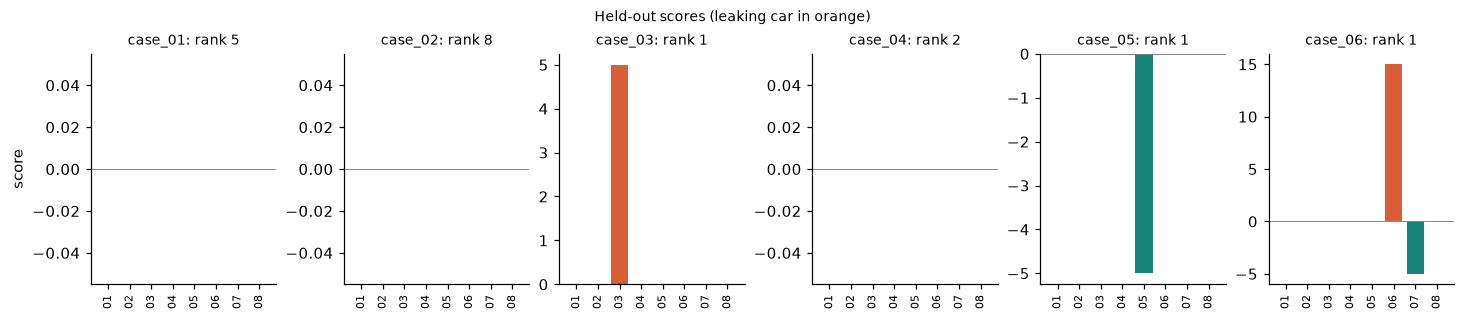

In [24]:
result = run_experiment('baseline', 'peer_median_rule', lambda: RuleRanker('peer_delta_reading_median'),
                        params={'model': 'rule', 'feature': 'peer_delta_reading_median'})
show(result)

<blockquote><h3 id="5-3"><b>5.3 Mean Peer Difference</b></h3></blockquote>

Section 2.8 showed that many cars have a median peer difference of exactly zero: temperatures are recorded in
0.5-degree steps, so the median of a car's differences often lands on the same value as the other cars'. The
mean keeps small but consistent offsets. The second rule therefore uses the mean peer difference over the cooling
minutes of the one-minute grid, the grid being used because sampling rates differ between cases.

🏃 View run peer_mean_rule at: https://dagshub.com/kaz-uuu/lta-train-fault-detection.mlflow/#/experiments/4/runs/ec97e05096684186a47781ef3df759ea
🧪 View experiment at: https://dagshub.com/kaz-uuu/lta-train-fault-detection.mlflow/#/experiments/4


,fold,faulty_car,predicted_top_car,rank,rank_decay
case,,,,,
case_01,fold-01,01,01,1,1.000
case_02,fold-02,02,02,1,1.000
case_03,fold-03,03,03,1,1.000
case_04,fold-04,01,04,2,0.875
case_05,fold-05,04,04,1,1.000
case_06,fold-06,06,06,1,1.000


mean rank decay 0.979 (95% interval 0.938 to 1.000) | top-1 0.833 | random ranking 0.5625


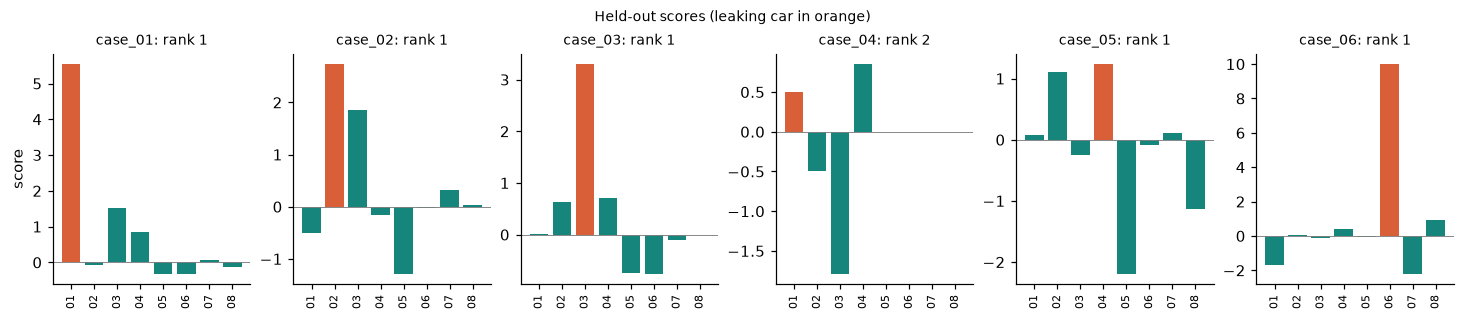

In [25]:
result = run_experiment('baseline', 'peer_mean_rule', lambda: RuleRanker('peer_delta_cooling_mean'),
                        params={'model': 'rule', 'feature': 'peer_delta_cooling_mean'})
show(result)

<blockquote><h3 id="5-4"><b>5.4 Median and Mean Compared</b></h3></blockquote>

For the leaking car of each Train case, the table sets its median peer difference, the number of other cars with
exactly the same median, and its rank under the median rule against its mean peer difference and rank, using
both the per-reading mean and the grid mean of the second rule. Ranks under the per-reading mean count tied cars
as one position.

In [26]:
compare_rows = []
for case in TRAIN_CASES:
    cars = CAR_TABLE[CAR_TABLE['case'].eq(case) & CAR_TABLE['minutes_with_indoor'].gt(0)].set_index('car')
    leaking = POSITIVES[case]
    median = cars.loc[leaking, 'peer_delta_reading_median']
    compare_rows.append({
        'case': case, 'leaking car': leaking, 'median difference': median,
        'other cars with the same median': int(cars['peer_delta_reading_median'].eq(median).sum() - 1),
        'rank by median': int(RESULTS[('baseline', 'peer_median_rule')]['per_case'].loc[case, 'rank']),
        'mean difference (readings)': cars.loc[leaking, 'peer_delta_reading_mean'],
        'rank by mean (readings)': int(cars['peer_delta_reading_mean'].rank(ascending=False, method='min')[leaking]),
        'mean difference (grid)': cars.loc[leaking, 'peer_delta_cooling_mean'],
        'rank by mean (grid)': int(RESULTS[('baseline', 'peer_mean_rule')]['per_case'].loc[case, 'rank'])})
display(pd.DataFrame(compare_rows).set_index('case').round(3))

,leaking car,median difference,other cars with the same median,rank by median,mean difference (readings),rank by mean (readings),mean difference (grid),rank by mean (grid)
case,,,,,,,,
case_01,01,0.0,7,5,0.479,1,0.500,1
case_02,02,0.0,7,8,0.254,1,0.251,1
case_03,03,0.5,0,1,0.626,1,0.626,1
case_04,01,0.0,3,2,0.224,2,0.226,2
case_05,04,0.0,6,1,0.205,1,0.206,1
case_06,06,1.5,0,1,1.363,1,1.353,1


<hr>

<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-6" style="color: black;"><b>Section 6: Pairwise Logistic Ranker</b></h2>
</div>

The first learned model combines all ten features into one linear score. It is trained on pairs of cars from the
same workbook, which matches the task: only the order of cars within a workbook matters, never their absolute
level. Its runs are recorded in the experiment `acv_logistic_ranker`: the full model, feature-group ablations, a
version with the invalid-state share, and two robustness checks.

<blockquote><h3 id="6-1"><b>6.1 Pairwise Training Examples</b></h3></blockquote>

Within every training workbook, the difference between the leaking car's features and each other car's features
is one example with target 1, and the reverse difference one example with target 0. A logistic regression without
intercept on these differences learns one weight per feature, and a car's score is its weighted feature sum.
Cars without evidence are left out of the pairs. The example below uses one workbook of three cars.

In [27]:
def pairwise_examples(design, labels, files):
    """Leaking-minus-other differences within each training file, in both orders (targets 1 and 0)."""
    rows, targets = [], []
    for file_id in np.unique(files):
        idx = np.flatnonzero(files == file_id)
        for p in idx[labels[idx] == 1]:
            for q in idx[labels[idx] == 0]:
                rows += [design[p] - design[q], design[q] - design[p]]
                targets += [1, 0]
    return np.asarray(rows), np.asarray(targets)


demo_pairs, demo_targets = pairwise_examples(np.array([[2.0, 1.0], [0.0, 0.5], [-1.0, 0.0]]), np.array([1, 0, 0]),
                                             np.array(['w', 'w', 'w']))
display(pd.DataFrame(demo_pairs, columns=['feature a', 'feature b']).assign(target=demo_targets))

,feature a,feature b,target
0,2.0,0.5,1
1,-2.0,-0.5,0
2,3.0,1.0,1
3,-3.0,-1.0,0


<blockquote><h3 id="6-2"><b>6.2 Logistic Ranker</b></h3></blockquote>

Features are standardised with constants from the training cases. The regularisation strength `C` is chosen from
0.01, 0.1 and 1 by an inner leave-one-group-out loop over the training cases only, and ties go to the smallest
value, the strongest regularisation. The grouping is by case, or by train in the leave-one-train-out check.

In [28]:
class PairwiseLogisticRanker(CarModel):
    """Linear score whose weights come from an L2 logistic regression on within-workbook pairs of cars."""

    def __init__(self, features, c_grid, group_col='case'):
        self.features, self.c_grid, self.group_col = list(features), list(c_grid), group_col

    def fit_fixed(self, frame, c):
        """Fit the weights for one value of C."""
        keep = car_evidence(frame)
        self.fit_medians(frame)
        X = self.design(frame)[0][keep]
        self.centre_, self.scale_ = X.mean(axis=0), X.std(axis=0)
        self.scale_[self.scale_ == 0] = 1.0
        pairs, targets = pairwise_examples((X - self.centre_) / self.scale_, frame['label'].to_numpy(dtype=int)[keep],
                                           frame['file_id'].to_numpy()[keep])
        self.c_ = c
        self.weights_ = LogisticRegression(C=c, fit_intercept=False, max_iter=5000).fit(pairs, targets).coef_.ravel()
        return self

    def fit(self, frame):
        """Choose C by inner leave-one-group-out on the training cases, then fit on all of them."""
        rows = []
        for held in sorted(frame[self.group_col].unique()):
            inner_train, inner_valid = frame[frame[self.group_col].ne(held)], frame[frame[self.group_col].eq(held)]
            for c in self.c_grid:
                ranked = PairwiseLogisticRanker(self.features, [c]).fit_fixed(inner_train, c).rank(inner_valid)
                for file_id, faulty in inner_valid.loc[inner_valid['label'].eq(1), ['file_id', 'car']].itertuples(index=False):
                    order = ranked.loc[ranked['file_id'].eq(file_id), 'car'].tolist()
                    rows.append({'inner_group': held, 'c': c, 'rank_decay': rank_decay(order, faulty)})
        self.search_ = pd.DataFrame(rows)
        means = self.search_.groupby('c')['rank_decay'].mean()
        return self.fit_fixed(frame, float(means[means == means.max()].index.min()))

    def scores(self, X):
        return ((X - self.centre_) / self.scale_) @ self.weights_


def logistic_params(features, group_col='case'):
    return {'model': 'pairwise_logistic', 'features': ','.join(features), 'n_features': len(features),
            'c_grid': ','.join(map(str, CONFIG['c_grid'])), 'inner_group': group_col}


def logistic_tables(result):
    """Fitted weights and chosen C of every fold."""
    folds = result['models']
    weights = pd.DataFrame({case: pd.Series(m.weights_, index=m.features) for case, m in folds.items()}).T
    return {'fold_weights': weights.assign(c=[m.c_ for m in folds.values()])}

<blockquote><h3 id="6-3"><b>6.3 All Features</b></h3></blockquote>

The full model uses the ten features of Section 2.9 and is the candidate from this architecture.

🏃 View run all_features at: https://dagshub.com/kaz-uuu/lta-train-fault-detection.mlflow/#/experiments/5/runs/e569509dece141c495bb13d628d4367d
🧪 View experiment at: https://dagshub.com/kaz-uuu/lta-train-fault-detection.mlflow/#/experiments/5


,fold,faulty_car,predicted_top_car,rank,rank_decay
case,,,,,
case_01,fold-01,01,01,1,1.000
case_02,fold-02,02,02,1,1.000
case_03,fold-03,03,03,1,1.000
case_04,fold-04,01,04,2,0.875
case_05,fold-05,04,04,1,1.000
case_06,fold-06,06,06,1,1.000


mean rank decay 0.979 (95% interval 0.938 to 1.000) | top-1 0.833 | random ranking 0.5625


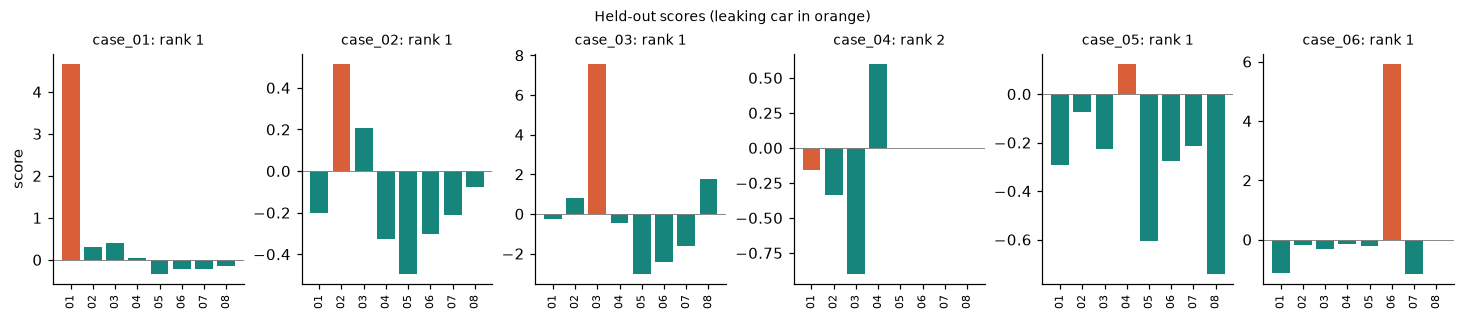

In [29]:
result = run_experiment('logistic_ranker', 'all_features', lambda: PairwiseLogisticRanker(FEATURES, CONFIG['c_grid']),
                        params=logistic_params(FEATURES), tables=logistic_tables)
show(result)

<blockquote><h3 id="6-4"><b>6.4 Feature-Group Ablations</b></h3></blockquote>

Each ablation removes or isolates one group of features to show which evidence the ranking relies on: peer
differences only, target errors only, everything except the ambient context (the indoor-outdoor slope and the
peer difference in hot minutes), and everything except persistence and recovery. These runs are diagnostics and
do not compete in the comparison.

In [30]:
PEER = ['peer_delta_cooling_mean', 'peer_delta_cooling_p90', 'peer_delta_hot_mean']
TARGET = ['target_error_cooling_mean', 'target_error_cooling_p90', 'above_target_share_cooling']
ABLATIONS = {
    'peer_only': PEER,
    'target_only': TARGET,
    'without_ambient': [f for f in FEATURES if f not in ['indoor_outdoor_slope_cooling', 'peer_delta_hot_mean']],
    'without_persistence_recovery': [f for f in FEATURES if f not in ['longest_warm_run_min', 'recovery_slope']],
}
for name, features in ABLATIONS.items():
    run_experiment('logistic_ranker', name, lambda features=features: PairwiseLogisticRanker(features, CONFIG['c_grid']),
                   params=logistic_params(features), role='variant')
display(rank_table([('logistic_ranker', 'all_features')] + [('logistic_ranker', n) for n in ABLATIONS]).round(3))

🏃 View run peer_only at: https://dagshub.com/kaz-uuu/lta-train-fault-detection.mlflow/#/experiments/5/runs/03181b668eb94adb94e5947b90e649bf
🧪 View experiment at: https://dagshub.com/kaz-uuu/lta-train-fault-detection.mlflow/#/experiments/5


🏃 View run target_only at: https://dagshub.com/kaz-uuu/lta-train-fault-detection.mlflow/#/experiments/5/runs/83396d2fccb1489782eed24a13bfd78c
🧪 View experiment at: https://dagshub.com/kaz-uuu/lta-train-fault-detection.mlflow/#/experiments/5


🏃 View run without_ambient at: https://dagshub.com/kaz-uuu/lta-train-fault-detection.mlflow/#/experiments/5/runs/9857d987f0ac40c2ae754ec059f69b33
🧪 View experiment at: https://dagshub.com/kaz-uuu/lta-train-fault-detection.mlflow/#/experiments/5


🏃 View run without_persistence_recovery at: https://dagshub.com/kaz-uuu/lta-train-fault-detection.mlflow/#/experiments/5/runs/d252041670944ace982aa293c5be9d66
🧪 View experiment at: https://dagshub.com/kaz-uuu/lta-train-fault-detection.mlflow/#/experiments/5


,case_01,case_02,case_03,case_04,case_05,case_06,rank decay
logistic_ranker / all_features,1.0,1.0,1.0,2.0,1.0,1.0,0.979
logistic_ranker / peer_only,1.0,1.0,1.0,2.0,2.0,1.0,0.958
logistic_ranker / target_only,1.0,1.0,1.0,2.0,1.0,1.0,0.979
logistic_ranker / without_ambient,1.0,1.0,1.0,2.0,1.0,1.0,0.979
logistic_ranker / without_persistence_recovery,1.0,1.0,1.0,2.0,1.0,1.0,0.979


<blockquote><h3 id="6-5"><b>6.5 Adding the Invalid-State Share</b></h3></blockquote>

Invalid running states cluster on the leaking car in the Train cases, and they may be how the operator's own
fault flag appears in the data, so the invalid-state share is kept out of the main feature set. This variant adds
it to show what, if anything, it would contribute.

In [31]:
WITH_INVALID = FEATURES + ['invalid_share']
run_experiment('logistic_ranker', 'with_invalid_share', lambda: PairwiseLogisticRanker(WITH_INVALID, CONFIG['c_grid']),
               params=logistic_params(WITH_INVALID), role='variant')
display(rank_table([('logistic_ranker', 'all_features'), ('logistic_ranker', 'with_invalid_share')]).round(3))

🏃 View run with_invalid_share at: https://dagshub.com/kaz-uuu/lta-train-fault-detection.mlflow/#/experiments/5/runs/551a40dc983645d5a2cefa28f7dba527
🧪 View experiment at: https://dagshub.com/kaz-uuu/lta-train-fault-detection.mlflow/#/experiments/5


,case_01,case_02,case_03,case_04,case_05,case_06,rank decay
logistic_ranker / all_features,1.0,1.0,1.0,2.0,1.0,1.0,0.979
logistic_ranker / with_invalid_share,1.0,1.0,1.0,2.0,1.0,1.0,0.979


<blockquote><h3 id="6-6"><b>6.6 Robustness Checks</b></h3></blockquote>

Two checks test whether the full model depends on particular cases. The first trains without `case_04`, the only
case of car model B, whose cars 05 to 08 are silent. The second holds out one train at a time, so that the two
cases from train 620, the train of the Test case, never support each other.

In [32]:
run_experiment('logistic_ranker', 'without_case_04', lambda: PairwiseLogisticRanker(FEATURES, CONFIG['c_grid']),
               params={**logistic_params(FEATURES), 'excluded_training_cases': 'case_04'}, role='variant', exclude=['case_04'])
run_experiment('logistic_ranker', 'leave_one_train_out',
               lambda: PairwiseLogisticRanker(FEATURES, CONFIG['c_grid'], group_col='train_number'),
               params=logistic_params(FEATURES, 'train_number'), role='variant', split=LOTRAIN)
display(rank_table([('logistic_ranker', n) for n in ['all_features', 'without_case_04', 'leave_one_train_out']]).round(3))

🏃 View run without_case_04 at: https://dagshub.com/kaz-uuu/lta-train-fault-detection.mlflow/#/experiments/5/runs/120192c3beff47e6ab264990eae5c81c
🧪 View experiment at: https://dagshub.com/kaz-uuu/lta-train-fault-detection.mlflow/#/experiments/5


🏃 View run leave_one_train_out at: https://dagshub.com/kaz-uuu/lta-train-fault-detection.mlflow/#/experiments/5/runs/cd682ef45f274b63b8a567a7b3dac068
🧪 View experiment at: https://dagshub.com/kaz-uuu/lta-train-fault-detection.mlflow/#/experiments/5


,case_01,case_02,case_03,case_04,case_05,case_06,rank decay
logistic_ranker / all_features,1.0,1.0,1.0,2.0,1.0,1.0,0.979
logistic_ranker / without_case_04,1.0,1.0,1.0,2.0,1.0,1.0,0.979
logistic_ranker / leave_one_train_out,1.0,1.0,1.0,2.0,1.0,1.0,0.979


<blockquote><h3 id="6-7"><b>6.7 Learned Weights</b></h3></blockquote>

The weights of the full model in each fold show which features drive the score and how stable they are when one
case is removed; weights apply to standardised features, so their sizes are comparable. The last column is the
chosen `C`.

In [33]:
display(logistic_tables(RESULTS[('logistic_ranker', 'all_features')])['fold_weights'].round(3))

,target_error_cooling_mean,target_error_cooling_p90,above_target_share_cooling,peer_delta_cooling_mean,peer_delta_cooling_p90,peer_delta_hot_mean,indoor_outdoor_slope_cooling,cooling_share_valid,longest_warm_run_min,recovery_slope,c
case_01,0.124,0.120,0.058,0.139,0.146,0.147,0.095,-0.073,0.075,0.068,0.01
case_02,0.124,0.097,0.073,0.132,0.129,0.152,0.085,-0.083,0.087,0.051,0.01
case_03,0.621,0.553,0.237,0.842,0.654,0.989,0.615,-0.622,0.257,0.400,1.00
case_04,0.146,0.141,0.074,0.150,0.153,0.148,0.073,0.017,0.082,0.016,0.01
case_05,0.130,0.091,0.071,0.141,0.176,0.120,0.072,-0.059,0.076,0.086,0.01
case_06,0.128,0.081,0.124,0.170,0.121,0.146,0.068,-0.069,0.054,0.060,0.01


<hr>

<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-7" style="color: black;"><b>Section 7: Gradient-Boosted Ranker</b></h2>
</div>

A linear score cannot represent thresholds or interactions, for example a peer difference that only matters when
the car is also far above its setpoint. Gradient-boosted trees can, and LightGBM's LambdaRank objective optimises
the order of cars within each training workbook directly. The run is recorded in the experiment `acv_gbm_ranker`.

<blockquote><h3 id="7-1"><b>7.1 LambdaRank Ranker</b></h3></blockquote>

The trees see the same within-case z-scores as the logistic ranker. With about 35 training cars per fold they are
kept very small: four leaves, at least three cars per leaf, and 100 rounds at a learning rate of 0.05. Cars
without evidence are left out of training.

In [34]:
class LambdaRankRanker(CarModel):
    """LightGBM LambdaRank on within-case z-scores, trained with one query group per workbook."""

    def __init__(self, features, params):
        self.features, self.params = list(features), dict(params)

    def fit(self, frame):
        frame = frame[car_evidence(frame)].sort_values(['file_id', 'car'])
        self.fit_medians(frame)
        self.model_ = lgb.LGBMRanker(objective='lambdarank', random_state=SEED, verbose=-1, **self.params)
        self.model_.fit(self.design(frame)[0], frame['label'].to_numpy(dtype=int),
                        group=frame.groupby('file_id', sort=True).size().to_numpy())
        return self

    def scores(self, X):
        return self.model_.predict(X)

<blockquote><h3 id="7-2"><b>7.2 LambdaRank on All Features</b></h3></blockquote>

The model uses the ten features of the logistic ranker and is the candidate from this architecture.

🏃 View run lambdarank at: https://dagshub.com/kaz-uuu/lta-train-fault-detection.mlflow/#/experiments/6/runs/3d451a3f5dd649fa96ed978f29047202
🧪 View experiment at: https://dagshub.com/kaz-uuu/lta-train-fault-detection.mlflow/#/experiments/6


,fold,faulty_car,predicted_top_car,rank,rank_decay
case,,,,,
case_01,fold-01,01,01,1,1.00
case_02,fold-02,02,02,1,1.00
case_03,fold-03,03,03,1,1.00
case_04,fold-04,01,04,3,0.75
case_05,fold-05,04,04,1,1.00
case_06,fold-06,06,06,1,1.00


mean rank decay 0.958 (95% interval 0.875 to 1.000) | top-1 0.833 | random ranking 0.5625


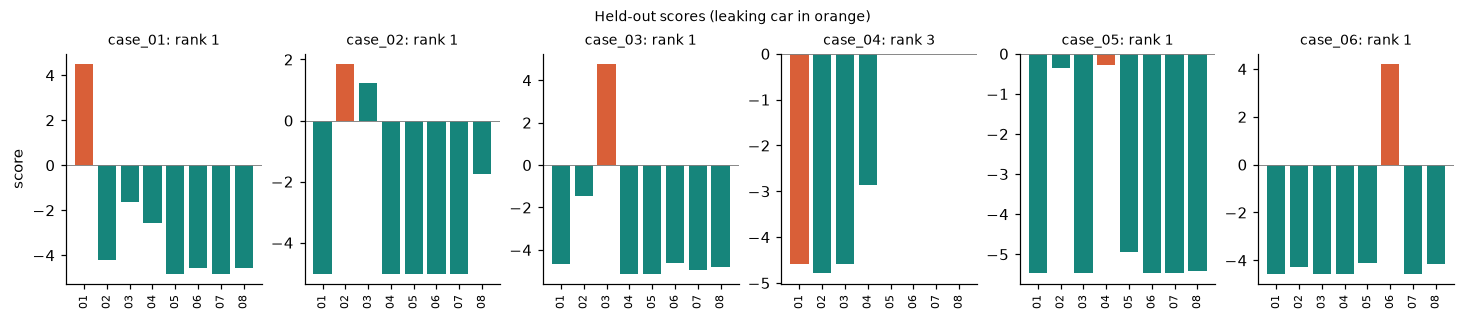

In [35]:
result = run_experiment('gbm_ranker', 'lambdarank', lambda: LambdaRankRanker(FEATURES, CONFIG['lambdarank']),
                        params={'model': 'lightgbm_lambdarank', 'features': ','.join(FEATURES),
                                'n_features': len(FEATURES), **CONFIG['lambdarank']})
show(result)

<blockquote><h3 id="7-3"><b>7.3 Feature Importance</b></h3></blockquote>

The total gain of each feature, averaged over the six folds, shows which features the trees split on.

In [36]:
gain = pd.DataFrame({case: pd.Series(m.model_.booster_.feature_importance('gain'), index=m.features)
                     for case, m in RESULTS[('gbm_ranker', 'lambdarank')]['models'].items()})
display(gain.mean(axis=1).sort_values(ascending=False).rename('mean gain').to_frame().round(2))

,mean gain
peer_delta_hot_mean,123.38
peer_delta_cooling_mean,23.88
target_error_cooling_mean,14.89
peer_delta_cooling_p90,10.65
longest_warm_run_min,8.79
cooling_share_valid,6.00
recovery_slope,4.30
indoor_outdoor_slope_cooling,2.74
above_target_share_cooling,1.70
target_error_cooling_p90,1.53


<hr>

<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-8" style="color: black;"><b>Section 8: Peer-Residual Model</b></h2>
</div>

The earlier models summarise each car before comparing it. This model works minute by minute instead: it learns
the cabin temperature a healthy car should have from the temperature of the other cars, its setpoint, the outdoor
temperature and the time of day, and ranks cars by how much warmer than expected they run while cooling. Two
regressors are compared in the experiment `acv_peer_residual`.

<blockquote><h3 id="8-1"><b>8.1 Minute Table</b></h3></blockquote>

The one-minute grid supplies the inputs of this model. Every row gets its `file_id`, the car's label and the hour
of day on a circle, so that 23:00 and 00:00 are neighbours. The silent cars of `case_04` have no minutes, so each
receives one empty row; this keeps them in the ranking, after every car with evidence.

In [37]:
RESIDUAL_INPUTS = ['peer_median', 'target', 'outdoor_train', 'hour_sin', 'hour_cos']
grid = minutes.astype({'case': str, 'car': str})
silent = CAR_TABLE.loc[CAR_TABLE['minutes_with_indoor'].eq(0), ['case', 'car']]
MINUTE_TABLE = pd.concat([grid, silent.assign(cooling=False, peers=0)], ignore_index=True)
MINUTE_TABLE = MINUTE_TABLE.assign(file_id=MINUTE_TABLE['case'].map(FILE_ID),
                                   hour_sin=np.sin(2 * np.pi * MINUTE_TABLE['hour'] / 24),
                                   hour_cos=np.cos(2 * np.pi * MINUTE_TABLE['hour'] / 24))
MINUTE_TABLE = (MINUTE_TABLE.join(CAR_TABLE.set_index(['case', 'car'])['label'], on=['case', 'car'])
                .sort_values(['file_id', 'car', 'minute']).reset_index(drop=True))
usable = MINUTE_TABLE['cooling'] & MINUTE_TABLE['peers'].ge(CONFIG['min_peers']) & MINUTE_TABLE[['indoor'] + RESIDUAL_INPUTS].notna().all(axis=1)
display(pd.DataFrame({'rows': MINUTE_TABLE.groupby('case').size(), 'usable cooling minutes': usable.groupby(MINUTE_TABLE['case']).sum(),
                      'cars': MINUTE_TABLE.groupby('case')['car'].nunique()}))

,rows,usable cooling minutes,cars
case,,,
case_01,27120,25226,8
case_02,34944,34567,8
case_03,33856,33417,8
case_04,14880,14291,8
case_05,26064,25724,8
case_06,11976,11281,8
test_case,33448,32881,8


<blockquote><h3 id="8-2"><b>8.2 Peer-Residual Ranker</b></h3></blockquote>

The regressor is fitted on the usable minutes of healthy cars in the training cases only: cooling, at least three
peers reporting, and all inputs present. For a held-out workbook, each car's residual is its measured cabin
temperature minus the expected one, averaged over its usable minutes, and the score is the within-case z-score of
that mean residual. A car without usable minutes has no evidence.

In [38]:
class PeerResidualRanker:
    """Ranks cars by how much warmer than a healthy-car regression they run while cooling."""

    input_level = 'minute'
    row_key = ['file_id', 'car', 'minute']
    input_columns = ['file_id', 'car', 'minute', 'indoor', 'cooling', 'peers'] + RESIDUAL_INPUTS

    def __init__(self, make_regressor, min_peers):
        self.make_regressor, self.min_peers = make_regressor, min_peers

    def usable(self, frame):
        return (frame['cooling'].astype(bool) & frame['peers'].ge(self.min_peers)
                & frame[['indoor'] + RESIDUAL_INPUTS].notna().all(axis=1)).to_numpy()

    def fit(self, frame):
        rows = frame[self.usable(frame) & frame['label'].eq(0).to_numpy()]
        self.regressor_ = self.make_regressor().fit(rows[RESIDUAL_INPUTS], rows['indoor'])
        return self

    def residuals(self, frame):
        rows = frame[self.usable(frame)]
        return rows[['file_id', 'car']].assign(residual=rows['indoor'].to_numpy() - self.regressor_.predict(rows[RESIDUAL_INPUTS]))

    def rank(self, frame):
        mean_residual = self.residuals(frame).groupby(['file_id', 'car'])['residual'].mean().rename('mean_residual')
        cars = frame[['file_id', 'car']].drop_duplicates().join(mean_residual, on=['file_id', 'car'])
        score = cars.groupby('file_id')['mean_residual'].transform(robust_z, SCALE_FLOOR['mean_residual'])
        ranked = rank_by_score(cars['file_id'].to_numpy(), cars['car'].to_numpy(), score.to_numpy(),
                               cars['mean_residual'].notna().to_numpy())
        return ranked.join(mean_residual, on=['file_id', 'car'])


def residual_params(regressor, settings):
    return {'model': 'peer_residual', 'regressor': regressor, 'inputs': ','.join(RESIDUAL_INPUTS),
            'min_peers': CONFIG['min_peers'], **settings}

<blockquote><h3 id="8-3"><b>8.3 Ridge Regression</b></h3></blockquote>

The first regressor is linear: standardised inputs and a ridge penalty of 1.

🏃 View run ridge at: https://dagshub.com/kaz-uuu/lta-train-fault-detection.mlflow/#/experiments/7/runs/127a2b1cbb794edc87ec386428713428
🧪 View experiment at: https://dagshub.com/kaz-uuu/lta-train-fault-detection.mlflow/#/experiments/7


,fold,faulty_car,predicted_top_car,rank,rank_decay
case,,,,,
case_01,fold-01,01,01,1,1.000
case_02,fold-02,02,02,1,1.000
case_03,fold-03,03,03,1,1.000
case_04,fold-04,01,04,2,0.875
case_05,fold-05,04,04,1,1.000
case_06,fold-06,06,06,1,1.000


mean rank decay 0.979 (95% interval 0.938 to 1.000) | top-1 0.833 | random ranking 0.5625


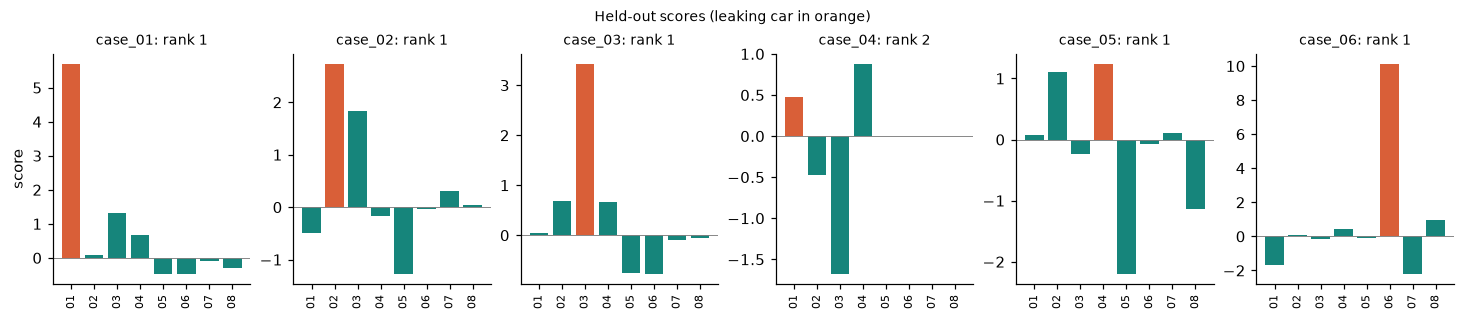

In [39]:
result = run_experiment('peer_residual', 'ridge',
                        lambda: PeerResidualRanker(lambda: make_pipeline(StandardScaler(), Ridge(alpha=CONFIG['ridge_alpha'])),
                                                   CONFIG['min_peers']),
                        params=residual_params('ridge', {'alpha': CONFIG['ridge_alpha']}))
show(result)

<blockquote><h3 id="8-4"><b>8.4 Histogram Gradient Boosting</b></h3></blockquote>

The second regressor can follow non-linear effects, for example a cabin that stops tracking its peers on hot
afternoons. It has 200 iterations at most, 15 leaves per tree and a learning rate of 0.1.

🏃 View run hist_gradient_boosting at: https://dagshub.com/kaz-uuu/lta-train-fault-detection.mlflow/#/experiments/7/runs/d5b703171d3143c89ebcb801fd171e1a
🧪 View experiment at: https://dagshub.com/kaz-uuu/lta-train-fault-detection.mlflow/#/experiments/7


,fold,faulty_car,predicted_top_car,rank,rank_decay
case,,,,,
case_01,fold-01,01,01,1,1.000
case_02,fold-02,02,02,1,1.000
case_03,fold-03,03,03,1,1.000
case_04,fold-04,01,04,2,0.875
case_05,fold-05,04,04,1,1.000
case_06,fold-06,06,06,1,1.000


mean rank decay 0.979 (95% interval 0.938 to 1.000) | top-1 0.833 | random ranking 0.5625


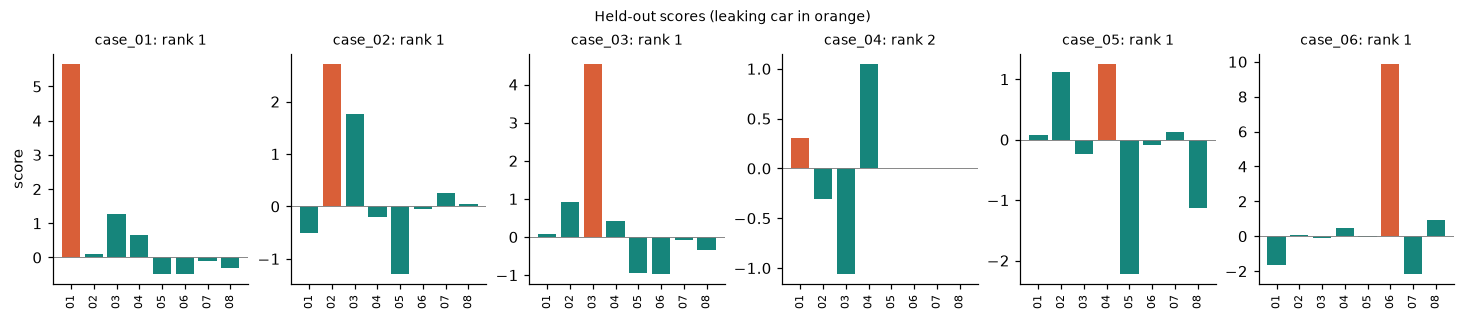

In [40]:
result = run_experiment('peer_residual', 'hist_gradient_boosting',
                        lambda: PeerResidualRanker(lambda: HistGradientBoostingRegressor(random_state=SEED,
                                                                                         **CONFIG['hist_gradient_boosting']),
                                                   CONFIG['min_peers']),
                        params=residual_params('hist_gradient_boosting', CONFIG['hist_gradient_boosting']))
show(result)

<blockquote><h3 id="8-5"><b>8.5 Residuals of Healthy and Leaking Cars</b></h3></blockquote>

A useful expected temperature should leave small residuals for healthy cars and a clearly positive one for the
leaking car. For each held-out Train case and regressor, the table gives the mean absolute residual of the healthy
cars and the mean residual of the leaking car, in degrees.

In [41]:
residual_rows = []
for name in ['ridge', 'hist_gradient_boosting']:
    for case, model in RESULTS[('peer_residual', name)]['models'].items():
        res = model.residuals(frame_for('minute', [case]))
        leaking = res['car'].eq(POSITIVES[case])
        residual_rows.append({'regressor': name, 'case': case,
                              'healthy cars: mean absolute residual': res.loc[~leaking, 'residual'].abs().mean(),
                              'leaking car: mean residual': res.loc[leaking, 'residual'].mean()})
residual_table = pd.DataFrame(residual_rows).set_index(['regressor', 'case']).unstack('regressor')
display(residual_table.reindex(columns=['ridge', 'hist_gradient_boosting'], level='regressor').round(3))

healthy cars: mean absolute residual                        leaking car: mean residual                       
regressor                                ridge hist_gradient_boosting                      ridge hist_gradient_boosting
case                                                                                                                   
case_01                                  0.332                  0.341                      0.579                  0.530
case_02                                  0.305                  0.313                      0.274                  0.268
case_03                                  0.371                  0.392                      0.690                  0.746
case_04                                  0.552                  0.585                      0.218                 -0.070
case_05                                  0.285                  0.404                      0.135                 -0.045
case_06                                  0.420                  0.572                      1.374                  1.163

<hr>

<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-9" style="color: black;"><b>Section 9: Model Comparison</b></h2>
</div>

This section puts all architectures side by side, using the runs as recorded in MLflow, and selects the model
to carry forward.

<blockquote><h3 id="9-1"><b>9.1 Results Across Experiments</b></h3></blockquote>

The runs of this execution are read back from the tracking server by their `notebook_run` tag, so the comparison
uses exactly what was recorded. The table lists every run in the order it was built, with its mean held-out rank
decay, the fold bootstrap interval, top-1 accuracy and the rank of the leaking car in each case.

In [42]:
EXPERIMENTS = [f'acv_{arch}' for arch in dict.fromkeys(arch for arch, _ in RESULTS)]
LABELS = [f'{arch} / {name}' for arch, name in RESULTS]
experiment_names = {experiment_id(name): name.removeprefix('acv_') for name in EXPERIMENTS}
runs = mlflow.search_runs(experiment_names=EXPERIMENTS, filter_string=f"tags.notebook_run = '{NOTEBOOK_RUN}'")
runs.index = runs['experiment_id'].map(experiment_names) + ' / ' + runs['tags.mlflow.runName']
runs = runs[runs['tags.role'].ne('final')].reindex(LABELS)
assert runs['run_id'].notna().all(), 'Some runs of this execution were not found on the tracking server.'
COMPARISON = pd.DataFrame({'role': runs['tags.role'], 'split': runs['tags.split'], 'rank decay': runs['metrics.rank_decay'],
                           'CI low': runs['metrics.rank_decay_ci_low'], 'CI high': runs['metrics.rank_decay_ci_high'],
                           'top-1': runs['metrics.top1_accuracy'],
                           **{case: runs[f'metrics.rank_{case}'].astype('Int64') for case in TRAIN_CASES}})
display(COMPARISON.round(3))

,role,split,rank decay,CI low,CI high,top-1,case_01,case_02,case_03,case_04,case_05,case_06
baseline / peer_median_rule,candidate,leave-one-case-out,0.750,0.458,0.979,0.500,5,8,1,2,1,1
baseline / peer_mean_rule,candidate,leave-one-case-out,0.979,0.938,1.000,0.833,1,1,1,2,1,1
logistic_ranker / all_features,candidate,leave-one-case-out,0.979,0.938,1.000,0.833,1,1,1,2,1,1
logistic_ranker / peer_only,variant,leave-one-case-out,0.958,0.917,1.000,0.667,1,1,1,2,2,1
logistic_ranker / target_only,variant,leave-one-case-out,0.979,0.938,1.000,0.833,1,1,1,2,1,1
logistic_ranker / without_ambient,variant,leave-one-case-out,0.979,0.938,1.000,0.833,1,1,1,2,1,1
logistic_ranker / without_persistence_recovery,variant,leave-one-case-out,0.979,0.938,1.000,0.833,1,1,1,2,1,1
logistic_ranker / with_invalid_share,variant,leave-one-case-out,0.979,0.938,1.000,0.833,1,1,1,2,1,1
logistic_ranker / without_case_04,variant,leave-one-case-out,0.979,0.938,1.000,0.833,1,1,1,2,1,1
logistic_ranker / leave_one_train_out,variant,leave-one-train-out,0.979,0.925,1.000,0.833,1,1,1,2,1,1


<blockquote><h3 id="9-2"><b>9.2 Comparison Plot</b></h3></blockquote>

The plot shows the mean held-out rank decay of every run with its bootstrap interval. Candidates, one or two per
architecture, are coloured; diagnostic variants are grey. The dashed line is the score of a random ranking.

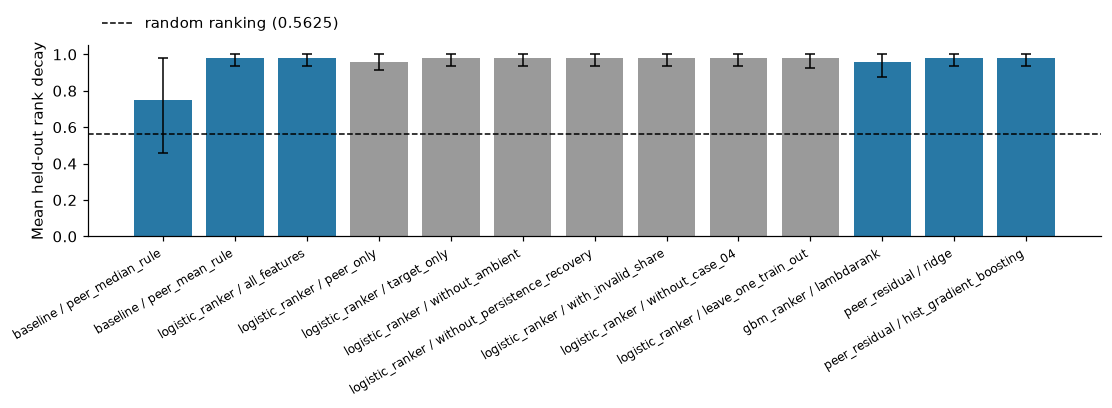

In [43]:
comparison_figure(COMPARISON)
plt.show()

<blockquote><h3 id="9-3"><b>9.3 Model Selection</b></h3></blockquote>

The selected model is the candidate with the highest mean held-out rank decay. When candidates tie, the simplest
wins, following the order in which the architectures were built, since added complexity has to earn its place.
Three points limit what the comparison can show. Every score rests on six cases, so moving the leaking car by one
place in one case changes the mean by about 0.02. The features were chosen during the exploratory analysis with
all six labels in view, so every score is optimistic. And a rule has nothing fitted, so its held-out score is
also its score on the cases it was designed with.

In [44]:
candidates = COMPARISON[COMPARISON['role'].eq('candidate')]
best = candidates.index[np.isclose(candidates['rank decay'], candidates['rank decay'].max())].tolist()
SELECTED = list(RESULTS)[LABELS.index(best[0])]
client.set_tag(RESULTS[SELECTED]['run_id'], 'selected', 'true')
display(candidates[['rank decay', 'CI low', 'CI high', 'top-1']].assign(selected=candidates.index == best[0]).round(3))
print('Selected:', best[0], '| other candidates with the same score:', ', '.join(best[1:]) or 'none')

,rank decay,CI low,CI high,top-1,selected
baseline / peer_median_rule,0.750,0.458,0.979,0.500,False
baseline / peer_mean_rule,0.979,0.938,1.000,0.833,True
logistic_ranker / all_features,0.979,0.938,1.000,0.833,False
gbm_ranker / lambdarank,0.958,0.875,1.000,0.833,False
peer_residual / ridge,0.979,0.938,1.000,0.833,False
peer_residual / hist_gradient_boosting,0.979,0.938,1.000,0.833,False


Selected: baseline / peer_mean_rule | other candidates with the same score: logistic_ranker / all_features, peer_residual / ridge, peer_residual / hist_gradient_boosting


<hr>

<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-10" style="color: black;"><b>Section 10: Final Model</b></h2>
</div>

This section refits the selected configuration on all Train cases, packages it as an MLflow model with input
checks, registers it, and ranks the cars of the Test case.

<blockquote><h3 id="10-1"><b>10.1 Refit on All Train Cases</b></h3></blockquote>

The selected configuration is fitted on all six Train cases in a run named `final_refit`, inside the experiment
of its architecture and linked to the evaluation run it came from. No score is reported for the refit, because it
would be measured on the cases it was fitted on.

In [45]:
ARCH, NAME = SELECTED
chosen = RESULTS[SELECTED]
FINAL_MODEL = chosen['make_model']()
start = time.perf_counter()
FINAL_MODEL.fit(frame_for(FINAL_MODEL.input_level, TRAIN_CASES))
fit_seconds = time.perf_counter() - start
with mlflow.start_run(experiment_id=experiment_id(f'acv_{ARCH}'), run_name='final_refit',
                      tags={'notebook_run': NOTEBOOK_RUN, **GIT, 'data_version': DATA_VERSION, 'role': 'final',
                            'evaluation_run_id': chosen['run_id']}) as final_run:
    mlflow.log_params({**chosen['params'], 'training_cases': ' '.join(TRAIN_CASES), 'seed': SEED})
    mlflow.log_metric('fit_time_s', fit_seconds)
FINAL_RUN_ID = final_run.info.run_id
display(pd.Series({'experiment': f'acv_{ARCH}', 'configuration': NAME, **chosen['params']}, name='value').to_frame())

🏃 View run final_refit at: https://dagshub.com/kaz-uuu/lta-train-fault-detection.mlflow/#/experiments/4/runs/0149e22792f14f3395a6b0b64cf7f2e7
🧪 View experiment at: https://dagshub.com/kaz-uuu/lta-train-fault-detection.mlflow/#/experiments/4


,value
experiment,acv_baseline
configuration,peer_mean_rule
model,rule
feature,peer_delta_cooling_mean


<blockquote><h3 id="10-2"><b>10.2 Model Package</b></h3></blockquote>

The fitted model is wrapped as an MLflow Python model. Its input is the table the model was trained on: one row
per car for the car-level models, or one row per car and minute for the peer-residual model, always with
`file_id` and `car`. The wrapper rejects missing columns, car identifiers that are not two-digit strings, repeated
rows, workbooks with fewer than two cars (scores are relative within a workbook) and infinite values, and returns
every car's score and rank. The example below is part of one Train case.

In [46]:
class AcvRankerPackage(mlflow.pyfunc.PythonModel):
    """Checks the input table, then scores and ranks every car of each workbook."""

    def __init__(self, model):
        self.model = model

    def predict(self, context, model_input: pd.DataFrame, params=None) -> pd.DataFrame:
        frame = pd.DataFrame(model_input).copy()
        missing = [c for c in self.model.input_columns if c not in frame.columns]
        if missing:
            raise ValueError(f'Missing required columns: {missing}')
        frame['car'] = frame['car'].astype(str)
        if not frame['car'].str.fullmatch(r'\d{2}').all():
            raise ValueError('Car identifiers must be two-digit strings as in the workbook headers, e.g. "03".')
        if frame.duplicated(self.model.row_key).any():
            raise ValueError(f'Rows must be unique by {self.model.row_key}.')
        if frame.groupby('file_id')['car'].nunique().lt(2).any():
            raise ValueError('Each workbook needs at least two cars; supply every car of the workbook.')
        if np.isinf(frame[self.model.input_columns].select_dtypes('number').to_numpy(dtype=float)).any():
            raise ValueError('Values must be finite or missing.')
        return self.model.rank(frame[self.model.input_columns])


PACKAGE = AcvRankerPackage(FINAL_MODEL)
EXAMPLE = frame_for(FINAL_MODEL.input_level, [TRAIN_CASES[0]])[FINAL_MODEL.input_columns]
if FINAL_MODEL.input_level == 'minute':
    EXAMPLE = EXAMPLE.groupby('car').head(30).reset_index(drop=True)
with warnings.catch_warnings():
    warnings.filterwarnings('ignore', message='Hint: Inferred schema contains integer')  # `rank` is an integer by design
    SIGNATURE = infer_signature(EXAMPLE, PACKAGE.predict(None, EXAMPLE))
display(PACKAGE.predict(None, EXAMPLE))

,file_id,car,score,has_evidence,rank,imputed_features
0,acv_case_01.xlsx,01,5.537892,True,1,0
1,acv_case_01.xlsx,03,1.515368,True,2,0
2,acv_case_01.xlsx,04,0.853533,True,3,0
3,acv_case_01.xlsx,07,0.078422,True,4,0
4,acv_case_01.xlsx,02,-0.078422,True,5,0
5,acv_case_01.xlsx,08,-0.139813,True,6,0
6,acv_case_01.xlsx,05,-0.312104,True,7,0
7,acv_case_01.xlsx,06,-0.320025,True,8,0


<blockquote><h3 id="10-3"><b>10.3 Registration</b></h3></blockquote>

The package is logged to the `final_refit` run with its signature, an input example and pinned requirements,
and registered as a new version of `acv_car_ranker` with a short description. The new version receives the
`champion` alias. The model is serialised with cloudpickle because it is defined in this notebook.

In [47]:
PINS = [f'{n}=={importlib.metadata.version(n)}' for n in ['mlflow', 'numpy', 'pandas', 'scikit-learn', 'lightgbm', 'cloudpickle']]
DESCRIPTION = (f"Ranks the cars of an ACV workbook from most to least likely to be leaking refrigerant. Configuration "
               f"{ARCH} / {NAME}, refitted on the six Train cases; mean held-out rank decay {chosen['summary']['rank_decay']:.3f} "
               f"with leave-one-case-out validation.")
pyfunc_logger = logging.getLogger('mlflow.pyfunc')
previous_level = pyfunc_logger.level
pyfunc_logger.setLevel(logging.ERROR)  # silences the notice about pickled models, which are produced here
try:
    with mlflow.start_run(run_id=FINAL_RUN_ID):
        MODEL_INFO = mlflow.pyfunc.log_model(name='model', python_model=PACKAGE, signature=SIGNATURE,
                                             input_example=EXAMPLE, pip_requirements=PINS)
finally:
    pyfunc_logger.setLevel(previous_level)
with contextlib.redirect_stderr(io.StringIO()):
    MODEL_VERSION = mlflow.register_model(MODEL_INFO.model_uri, CONFIG['registered_model']).version
client.update_model_version(CONFIG['registered_model'], MODEL_VERSION, description=DESCRIPTION)
client.set_registered_model_alias(CONFIG['registered_model'], 'champion', MODEL_VERSION)
print(f"Registered {CONFIG['registered_model']} version {MODEL_VERSION} with alias champion.")

🏃 View run final_refit at: https://dagshub.com/kaz-uuu/lta-train-fault-detection.mlflow/#/experiments/4/runs/0149e22792f14f3395a6b0b64cf7f2e7
🧪 View experiment at: https://dagshub.com/kaz-uuu/lta-train-fault-detection.mlflow/#/experiments/4


Registered acv_car_ranker version 1 with alias champion.


<blockquote><h3 id="10-4"><b>10.4 Submission Format</b></h3></blockquote>

The submission file `acv_predictions.csv` has one row per workbook: `file_id`, the workbook file name with its
extension, and `ranked_cars`, every car identifier from the workbook headers exactly once, joined by `|` from
most to least likely leaking. The validator is tested on two malformed rows.

In [48]:
HEADER_ROSTER = mapping.drop_duplicates(['workbook', 'car']).groupby('workbook')['car'].agg(sorted).to_dict()


def export_rows(ranked):
    """One `file_id,ranked_cars` row per workbook, cars joined by '|' from most to least likely leaking."""
    ordered = ranked.sort_values(['file_id', 'rank'])
    return ordered.groupby('file_id', sort=True)['car'].agg('|'.join).rename('ranked_cars').reset_index()


def validate_export(rows, roster):
    """Every problem with a submission table: columns, repeated or unknown workbooks, missing or repeated cars."""
    problems = []
    if list(rows.columns) != ['file_id', 'ranked_cars']:
        problems.append('columns must be file_id,ranked_cars')
    if rows['file_id'].duplicated().any():
        problems.append('repeated file_id')
    for file_id, text in zip(rows['file_id'], rows['ranked_cars']):
        cars = str(text).split('|')
        if file_id not in roster:
            problems.append(f'{file_id}: unknown workbook')
        elif sorted(cars) != roster[file_id] or len(set(cars)) != len(cars):
            problems.append(f'{file_id}: cars must match the header roster, once each')
    return problems


display(pd.DataFrame({'row': ['acv_case_01.xlsx with two cars', 'acv_case_01 without its extension'],
                      'problems found': [validate_export(pd.DataFrame({'file_id': ['acv_case_01.xlsx'], 'ranked_cars': ['01|02']}), HEADER_ROSTER),
                                         validate_export(pd.DataFrame({'file_id': ['acv_case_01'], 'ranked_cars': ['|'.join(CARS8)]}), HEADER_ROSTER)]}))

,row,problems found
0,acv_case_01.xlsx with two cars,[acv_case_01.xlsx: cars must match the header ...
1,acv_case_01 without its extension,[acv_case_01: unknown workbook]


<blockquote><h3 id="10-5"><b>10.5 Package Checks</b></h3></blockquote>

The registered version is loaded back from the registry and applied to all Train cases. It has to reproduce the
scores and ranks of the fitted model exactly, reject each kind of malformed input, and produce Train rankings
that pass the submission format.

In [49]:
LOADED = mlflow.pyfunc.load_model(f"models:/{CONFIG['registered_model']}@champion")
FIXTURE = frame_for(FINAL_MODEL.input_level, TRAIN_CASES)[FINAL_MODEL.input_columns]
expected, reloaded = FINAL_MODEL.rank(FIXTURE), LOADED.predict(FIXTURE)


def rejects(frame):
    """True when the registered version refuses `frame`."""
    try:
        LOADED.predict(frame)
    except Exception:
        return True
    return False


last = FINAL_MODEL.input_columns[-1]
PACKAGE_CHECKS = {
    'reproduces the fitted scores and ranks': bool(
        np.allclose(expected['score'], reloaded['score'], rtol=0, atol=1e-12, equal_nan=True)
        and expected[['file_id', 'car', 'rank']].equals(reloaded[['file_id', 'car', 'rank']])),
    'rejects a missing column': rejects(FIXTURE.drop(columns=[last])),
    'rejects malformed car identifiers': rejects(FIXTURE.assign(car='Car 3')),
    'rejects a repeated row': rejects(pd.concat([FIXTURE.head(1), FIXTURE])),
    'rejects a workbook with one car': rejects(FIXTURE[FIXTURE['car'].eq(FIXTURE['car'].iloc[0])]),
    'rejects infinite values': rejects(FIXTURE.assign(**{last: np.inf})),
    'Train rankings pass the submission format': not validate_export(export_rows(reloaded), HEADER_ROSTER),
}
assert all(PACKAGE_CHECKS.values())
display(pd.Series(PACKAGE_CHECKS, name='passed').to_frame())

,passed
reproduces the fitted scores and ranks,True
rejects a missing column,True
rejects malformed car identifiers,True
rejects a repeated row,True
rejects a workbook with one car,True
rejects infinite values,True
Train rankings pass the submission format,True


<blockquote><h3 id="10-6"><b>10.6 Test-Case Ranking</b></h3></blockquote>

The Test case is ranked only now, after the model has been selected and registered, so its ranking could not
influence any modelling choice. The registered version ranks its cars, and the result is converted to the
submission format, validated, read back to confirm that leading zeros survive, and attached to the `final_refit`
run.

In [50]:
TEST_INPUT = frame_for(FINAL_MODEL.input_level, ['test_case'])[FINAL_MODEL.input_columns]
TEST_RANKED = LOADED.predict(TEST_INPUT)
SUBMISSION = export_rows(TEST_RANKED)
assert not validate_export(SUBMISSION, HEADER_ROSTER)
SUBMISSION_PATH = OUTPUT_DIR / 'acv_predictions.csv'
SUBMISSION.to_csv(SUBMISSION_PATH, index=False)
assert pd.read_csv(SUBMISSION_PATH, dtype=str).equals(SUBMISSION)
with mlflow.start_run(run_id=FINAL_RUN_ID):
    mlflow.log_artifact(str(SUBMISSION_PATH))
    mlflow.log_text(TEST_RANKED.to_csv(index=False), 'test_car_scores.csv')
display(SUBMISSION)
display(TEST_RANKED)

🏃 View run final_refit at: https://dagshub.com/kaz-uuu/lta-train-fault-detection.mlflow/#/experiments/4/runs/0149e22792f14f3395a6b0b64cf7f2e7
🧪 View experiment at: https://dagshub.com/kaz-uuu/lta-train-fault-detection.mlflow/#/experiments/4


,file_id,ranked_cars
0,acv_test_case.xlsx,01|03|04|07|08|06|02|05


,file_id,car,score,has_evidence,rank,imputed_features
0,acv_test_case.xlsx,01,1.098262,True,1,0
1,acv_test_case.xlsx,03,0.617118,True,2,0
2,acv_test_case.xlsx,04,0.598460,True,3,0
3,acv_test_case.xlsx,07,0.064750,True,4,0
4,acv_test_case.xlsx,08,-0.064750,True,5,0
5,acv_test_case.xlsx,06,-0.164458,True,6,0
6,acv_test_case.xlsx,02,-0.645959,True,7,0
7,acv_test_case.xlsx,05,-1.003465,True,8,0


<blockquote><h3 id="10-7"><b>10.7 Evidence Margin</b></h3></blockquote>

The gap between the scores of the first- and second-ranked cars shows how clearly a ranking singles out one car.
The table sets the gap in each held-out Train case, from the selected configuration's cross-validation, against
the gap in the Test case, and marks whether the top Train car was the leaking one. Gaps are in the selected
model's score units. No Test label is inferred from them.

In [51]:
def top_gap(ranked):
    """First- and second-ranked cars of each workbook and the score gap between them."""
    ordered = ranked.sort_values(['file_id', 'rank'])
    gaps = ordered.groupby('file_id').agg(top_car=('car', 'first'), second_car=('car', lambda s: s.iloc[1]),
                                          gap=('score', lambda s: s.iloc[0] - s.iloc[1]))
    return gaps.set_axis(gaps.index.map(CASE_OF)).rename_axis('case')


train_gaps = top_gap(chosen['predictions'])
train_gaps['top car is leaking'] = [POSITIVES[case] == top for case, top in train_gaps['top_car'].items()]
display(pd.concat([train_gaps, top_gap(TEST_RANKED)]).round(3))

,top_car,second_car,gap,top car is leaking
case,,,,
case_01,01,03,4.023,True
case_02,02,03,0.869,True
case_03,03,04,2.587,True
case_04,04,01,0.350,False
case_05,04,02,0.126,True
case_06,06,08,9.058,True
test_case,01,03,0.481,NaN


<hr>

<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-11" style="color: black;"><b>Section 11: Conclusions</b></h2>
</div>

This section summarises what each architecture achieved, the model that was carried forward, and the limits of
the evidence. All statements refer to the executed results above.

<blockquote><h3 id="11-1"><b>11.1 Results by Architecture</b></h3></blockquote>

- **Baseline.** The median peer difference, the statistic of the exploratory analysis, reached a mean held-out
  rank decay of 0.750 with top-1 accuracy 0.500. It ranked the leaking car 5th in `case_01` and 8th in
  `case_02`, where the leaking car shares a median difference of 0 with the seven other cars. The mean peer
  difference over cooling minutes reached 0.979 (fold bootstrap interval 0.938 to 1.000, top-1 accuracy 0.833):
  the leaking car ranked first in five cases and second in `case_04`, behind car 04.
- **Logistic ranker.** The pairwise logistic ranker on all ten features gave the same rank as the mean rule in
  every case (0.979). Target errors alone, the model without ambient context and the model without persistence
  and recovery also left every rank unchanged, while peer differences alone moved the leaking car of `case_05`
  to second (0.958). Adding the invalid-state share changed no rank. Training without `case_04` and holding out
  one train at a time both gave 0.979. The inner search chose `C` = 0.01 in five folds and 1.0 in the fold
  that held out `case_03`.
- **Gradient-boosted ranker.** LambdaRank reached 0.958, ranking the leaking car of `case_04` third instead of
  second. Its largest gain came from the peer difference in hot minutes.
- **Peer-residual model.** Ridge and histogram gradient boosting both reached 0.979 with the same ranks as the
  mean rule. On held-out cases, the healthy cars' mean absolute residual was 0.285 to 0.585 degrees. The
  leaking car's mean residual ranged from -0.070 degrees (`case_04`, gradient boosting) to 1.374 degrees
  (`case_06`, ridge).

<blockquote><h3 id="11-2"><b>11.2 Selected Model and Test Ranking</b></h3></blockquote>

- Four candidates tied at 0.979 with identical ranks in every case: the mean peer-difference rule, the logistic
  ranker, and both peer-residual regressors. No added complexity improved on the baseline, so the selection
  rule kept the mean peer-difference rule.
- The rule was refitted on the six Train cases and registered as version 1 of `acv_car_ranker` with the alias
  `champion`. The registered version reproduced the fitted ranks and passed every package check.
- The Test ranking is `01|03|04|07|08|06|02|05`. The score gap between its first two cars is 0.481. Across the
  held-out Train cases, the correctly ranked cases had gaps of 0.126 to 9.058, and `case_04`, whose top car
  was not the leaking one, had a gap of 0.350.

<blockquote><h3 id="11-3"><b>11.3 Limitations</b></h3></blockquote>

- Every score rests on six cases. All four tied candidates share the interval 0.938 to 1.000, so the data
  cannot separate them. `case_04` is the only case that none of the architectures ranked correctly.
- The features were chosen during the exploratory analysis with all six labels in view, so the held-out scores
  are optimistic development estimates rather than an independent test.
- `case_04` is the only case of car model B, and cars 05 to 08 are silent. The preprocessing pressure check
  did not clearly support its label. Every candidate except the median rule ranked car 04 first there.
- The Test case comes from train 620, like `case_01` and `case_02`. Its raw feature values lie within the Train
  range for all ten features. On the within-case z-scores, one Test car lies outside the Train range, in the
  90th percentile of the target error.